## 🪴 Introducción

Este proyecto desarrolla una plataforma de análisis y predicción de la generación de energía renovable en España, centrada en la producción solar y eólica. Para ello, se construye un dataset propio mediante la integración de distintas fuentes públicas de información energética, meteorológica y de mercado.

A partir de estos datos se entrenarán y compararán diferentes modelos de Machine Learning para predecir la generación renovable, analizar los principales factores que influyen en ella y presentar los resultados de forma visual e interpretable.

Para representar la diversidad climática y geográfica de España, se seleccionaron diez ubicaciones distribuidas entre distintas zonas del territorio: 
| Ubicación | Coordenadas | Relevancia |
|---|---|---|
| Valencia | 39.47°N, 0.38°W | Representación del litoral mediterráneo y alto recurso solar |
| Cádiz | 36.53°N, 6.29°W | Elevado recurso eólico y solar del sur peninsular |
| Madrid | 40.42°N, 3.70°W | Representación de la zona central de la península |
| Bilbao | 43.26°N, 2.94°W | Representación del norte peninsular y clima atlántico |
| Cáceres | 39.48°N, 6.37°W | Representación del oeste peninsular y alto recurso solar |
| Tenerife* | 28.46°N, 16.25°W | Representación insular y condiciones meteorológicas diferenciadas |
| Zaragoza | 41.65°N, 0.89°W | Representación del valle del Ebro y de una zona con elevado recurso eólico |
| A Coruña | 43.36°N, 8.41°W | Representación del noroeste peninsular y de las condiciones atlánticas |
| Pamplona | 42.81°N, 1.65°W | Representación del noreste interior y de condiciones eólicas diferenciadas |
| Valladolid | 41.65°N, 4.72°W | Representación de la Meseta Norte y ampliación de la cobertura del interior peninsular |

<small>*Para simplificar la nomenclatura, en este proyecto se utiliza «Tenerife» para hacer referencia a Santa Cruz de Tenerife.</small>

## 💻 Instalar e importar librerías

In [1]:
%pip install -q pandas numpy matplotlib seaborn requests entsoe-py cdsapi shap scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import time
import cdsapi
import logging
import warnings

from pandas.errors import PerformanceWarning

# Reducir mensajes no relevantes en la salida del notebook
logging.disable(logging.INFO)
warnings.simplefilter("ignore", PerformanceWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import shap

from entsoe import EntsoePandasClient

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

## 🗃️ Fuente de datos 

| Dataset | Fuente 
|---|---|
| Generación renovable (solar y eólica terrestre) | ENTSO-E Transparency Platform API 
| Demanda total de la red eléctrica | ENTSO-E Transparency Platform API | 
| Precio del mercado eléctrico | Ember Energy (Spain.csv) | 
| Variables meteorológicas  | Open-Meteo Historical Weather API | 
| Radiación solar GHI | Copernicus CAMS Atmosphere Data Store | 


**10 ubicaciones meteorológicas:** Valencia, Cádiz, Madrid, Bilbao, Cáceres, Tenerife, Pamplona, Valladolid, A Coruña y Zaragoza.

**Periodo de análisis:** 2023-01-01 → 2026-06-30 | **Frecuencia final:** Horaria

⚠️<small>
(Para una ejecución más rápida del notebook y sin necesidad de configurar las credenciales de acceso a las distintas APIs, se puede pasar directamente al apartado de <b>Integración del dataset</b>. En dicho apartado se utilizan los archivos previamente descargados desde las fuentes originales e incluidos en la carpeta <code>Datasets</code>. Esto permite reproducir la construcción del dataset final y el posterior análisis sin repetir el proceso de extracción, que puede requerir un tiempo considerable.)
</small>

## ⚛️ ENTSO-E

Los datos del sistema eléctrico español se obtienen a través de la API de ENTSO-E Transparency Platform para el periodo comprendido entre enero de 2023 y junio de 2026. 

Debido a las limitaciones actuales de la API de ENTSO-E para la consulta de datos de generación, el periodo completo no puede descargarse mediante una única petición. Por este motivo, la extracción se realiza automáticamente en bloques de **28 días**, que posteriormente se concatenan para reconstruir la serie temporal completa. El uso de intervalos de 28 días permite mantener cada petición por debajo del límite mensual de la API y reducir el riesgo de errores asociados a los límites de los meses y a los cambios de horario.


<small>(A diferencia del resto de APIs utilizadas, el acceso a ENTSO-E requiere solicitar la activación de una clave personal, un proceso que puede tardar varios días. Por este motivo, el código de extracción se ha diseñado para reutilizar automáticamente los archivos previamente descargados cuando estos se encuentran disponibles y realizar la consulta a la API únicamente cuando sea necesario.)</small>

In [3]:
# Configuración inicial

API_TOKEN = "TU_API_TOKEN"
COUNTRY_CODE = "ES"

start_date = pd.Timestamp("2023-01-01", tz="Europe/Madrid")
end_date = pd.Timestamp("2026-07-01", tz="Europe/Madrid")

output_csv = "generacion_real_espana_2023_2026.csv"

# Si el archivo ya existe, se carga directamente
if os.path.exists(output_csv):

    print("📂 Archivo de generación encontrado. Cargando datos locales...")

    df_final = pd.read_csv(
        output_csv,
        header=[0, 1],
        index_col=0,
        parse_dates=True
    )

    df_final.index = pd.to_datetime(df_final.index, utc=True)
    df_final.index = df_final.index.tz_convert("Europe/Madrid")

    print("✅ Datos de generación cargados correctamente.")
    print(f"📊 Filas disponibles: {len(df_final)}")

# Si no existe, se descargan los datos desde ENTSO-E
else:

    client = EntsoePandasClient(api_key=API_TOKEN)

    print(
        f"🔄 Iniciando descarga desde "
        f"{start_date.date()} hasta {end_date.date()}..."
    )

    all_data = []
    chunk_start = start_date

    while chunk_start < end_date:

        chunk_end = min(
            chunk_start + pd.Timedelta(days=28),
            end_date
        )

        print(
            f"📥 Descargando "
            f"{chunk_start.date()} - {chunk_end.date()}..."
        )

        data_chunk = client.query_generation(
            country_code=COUNTRY_CODE,
            start=chunk_start,
            end=chunk_end,
            psr_type=None
        )

        all_data.append(data_chunk)
        chunk_start = chunk_end

        # Pausa entre peticiones por las limitaciones de la API
        time.sleep(1.5)

    # Unir todos los bloques
    print("🧩 Fusionando datos...")

    df_final = pd.concat(all_data)

    # Eliminar posibles timestamps duplicados
    df_final = df_final[
        ~df_final.index.duplicated(keep="first")
    ]

    # Guardar CSV
    df_final.to_csv(output_csv)

    print("✅ Descarga completada")
    print(f"📊 Archivo guardado: {output_csv}")
    print(f"📉 Filas obtenidas: {len(df_final)}")

📂 Archivo de generación encontrado. Cargando datos locales...
✅ Datos de generación cargados correctamente.
📊 Filas disponibles: 122437


#### Selección de generación renovable

A partir de los datos de generación descargados de ENTSO-E, se seleccionan las dos tecnologías renovables utilizadas como variables objetivo del proyecto: **generación solar** y **generación eólica terrestre**. Posteriormente, los datos se agregan a frecuencia horaria para hacerlos compatibles con el resto de las fuentes.

La generación eólica offshore se excluye al comprobar que presenta valores constantes de 0 durante el periodo analizado. Asimismo, se descartan otras tecnologías de generación al quedar fuera del alcance de los modelos predictivos definidos en este proyecto (nuclear, fosil, etc).

In [4]:
columnas_renovables = [
    ('Solar', 'Actual Aggregated'),
    ('Wind Onshore', 'Actual Aggregated')
]

generacion = df_final[columnas_renovables].copy()

generacion.columns = [
    'solar_mw',
    'eolica_onshore_mw'
]

# Eliminamos únicamente filas donde ambas variables sean nulas

generacion = generacion.dropna(how='all')

# Pasamos de 15 minutos a frecuencia horaria

generacion = generacion.resample('1h').mean()

print("Datos de generación filtrados correctamente")
print(f"Filas: {len(generacion)}")
print("Primeras filas:")

generacion.head()

Datos de generación filtrados correctamente
Filas: 30647
Primeras filas:


,solar_mw,eolica_onshore_mw
2023-01-01 00:00:00+01:00,20.0,6421.0
2023-01-01 01:00:00+01:00,20.0,5747.0
2023-01-01 02:00:00+01:00,20.0,5578.0
2023-01-01 03:00:00+01:00,20.0,5400.0
2023-01-01 04:00:00+01:00,20.0,4766.0


In [5]:
# Guardamos los datos de generación preparados para el análisis
generacion.to_csv("generacion_renovable_horaria_2023_2026.csv")

print("Archivo guardado correctamente")

Archivo guardado correctamente


### 🔋 Demanda total de la red eléctrica 

Además de los datos de generación, se obtiene de ENTSO-E la **demanda total de electricidad del sistema español** para el mismo periodo de análisis. Los datos se descargan mediante la API de ENTSO-E y se preparan a **frecuencia horaria** para facilitar su posterior integración con el resto de las fuentes.

In [6]:
# Archivo local de demanda
output_load_csv = "demanda_electrica_horaria_2023_2026.csv"

# Si el archivo ya existe, se carga directamente.
# En caso contrario, se descarga desde la API de ENTSO-E.
if os.path.exists(output_load_csv):

    print("📂 Archivo de demanda encontrado. Cargando datos locales...")

    demanda = pd.read_csv(
        output_load_csv,
        index_col=0,
        parse_dates=True
    )

    # Recuperar correctamente el índice temporal
    demanda.index = pd.to_datetime(demanda.index, utc=True)
    demanda.index = demanda.index.tz_convert("Europe/Madrid")

    print("✅ Datos de demanda cargados correctamente.")
    print(f"📊 Filas disponibles: {len(demanda)}")

else:

    client = EntsoePandasClient(api_key=API_TOKEN)

    all_load = []
    chunk_start = start_date

    while chunk_start < end_date:

        chunk_end = min(
            chunk_start + pd.Timedelta(days=28),
            end_date
        )

        print(
            f"Descargando demanda "
            f"{chunk_start.date()} - {chunk_end.date()}..."
        )

        for intento in range(3):

            try:
                load_chunk = client.query_load(
                    country_code=COUNTRY_CODE,
                    start=chunk_start,
                    end=chunk_end
                )

                all_load.append(load_chunk)
                break

            except Exception as e:

                if intento < 2:
                    print("Error temporal. Reintentando en 10 segundos...")
                    time.sleep(10)
                else:
                    raise e

        chunk_start = chunk_end
        time.sleep(1.5)

    # Unir todos los bloques
    demanda = pd.concat(all_load)

    # Eliminar posibles índices duplicados
    demanda = demanda[
        ~demanda.index.duplicated(keep="first")
    ]

    # Renombrar la columna
    demanda.columns = ["total_load_mw"]

    # Pasar a frecuencia horaria
    demanda = demanda.resample("1h").mean()

    # Guardar el archivo
    demanda.to_csv(output_load_csv)

    print("✅ Datos de demanda descargados correctamente.")
    print(f"📊 Filas: {len(demanda)}")

demanda.head()

📂 Archivo de demanda encontrado. Cargando datos locales...
✅ Datos de demanda cargados correctamente.
📊 Filas disponibles: 30647


,total_load_mw
2023-01-01 00:00:00+01:00,19997.0
2023-01-01 01:00:00+01:00,19251.0
2023-01-01 02:00:00+01:00,18104.0
2023-01-01 03:00:00+01:00,17090.0
2023-01-01 04:00:00+01:00,16531.0


## 🌡️ Open-Meteo

Para incorporar las condiciones meteorológicas asociadas a la generación renovable, se utilizan datos históricos obtenidos mediante la API de Open-Meteo para diez ubicaciones representativas de distintas zonas de España.

Se descargan variables relevantes para los modelos solar y eólico, incluyendo temperatura, velocidad y dirección del viento a 10 y 100 metros, ráfagas de viento a 10 metros, presión atmosférica, radiación solar y cobertura nubosa. Los datos se obtienen con frecuencia horaria para facilitar su integración con las demás fuentes del proyecto.

In [7]:
# Localizaciones seleccionadas

locations = {
    "Valencia": (39.4699, -0.3763),
    "Cadiz": (36.5271, -6.2886),
    "Madrid": (40.4168, -3.7038),
    "Bilbao": (43.2630, -2.9350),
    "Caceres": (39.4753, -6.3724),
    "Tenerife": (28.4636, -16.2518),
    "Zaragoza": (41.6488, -0.8891),
    "A_Coruna": (43.3623, -8.4115),
    "Pamplona": (42.8125, -1.6458),
    "Valladolid": (41.6523, -4.7245)
}


# API de Open-Meteo

url = "https://archive-api.open-meteo.com/v1/archive"

weather_data = {}


# Descarga de datos para cada localización

for city, (lat, lon) in locations.items():

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2023-01-01",
        "end_date": "2026-07-01",
        "hourly": ",".join([
            "temperature_2m",
            "wind_speed_10m",
            "wind_speed_100m",
            "wind_direction_10m",
            "wind_direction_100m",
            "wind_gusts_10m",
            "surface_pressure",
            "shortwave_radiation",
            "cloud_cover"
        ]),
        "timezone": "Europe/Madrid"
    }

    max_intentos = 5

    for intento in range(max_intentos):

        try:
            response = requests.get(
                url,
                params=params,
                timeout=60
            )

            if response.status_code == 200:

                data = response.json()
                df = pd.DataFrame(data["hourly"])

                weather_data[city] = df

                print(city, "-> OK")
                break

            elif response.status_code == 429:

                espera = 60 * (intento + 1)

                print(
                    city,
                    f"-> ERROR 429. Esperando {espera} segundos..."
                )

                time.sleep(espera)

            else:

                print(
                    city,
                    "-> ERROR",
                    response.status_code
                )

                break

        except requests.exceptions.RequestException as e:

            print(
                city,
                "-> ERROR de conexión:",
                e
            )

            time.sleep(60)

    else:
        print(
            city,
            "-> No se pudo descargar después de",
            max_intentos,
            "intentos"
        )

    # Pausa entre peticiones
    time.sleep(10)


# Guardar los datos descargados en CSV

for city, df in weather_data.items():

    df.to_csv(
        f"weather_{city}.csv",
        index=False
    )


print("\nDescarga finalizada.")
print(
    f"Localizaciones descargadas: "
    f"{len(weather_data)}/{len(locations)}"
)

Valencia -> OK
Cadiz -> OK
Madrid -> OK
Bilbao -> OK
Caceres -> OK
Tenerife -> OK
Zaragoza -> OK
A_Coruna -> OK
Pamplona -> OK
Valladolid -> OK

Descarga finalizada.
Localizaciones descargadas: 10/10


Los datos obtenidos mediante la API histórica de Open-Meteo se almacenan inicialmente en archivos CSV independientes para cada localización. Posteriormente, estos archivos se cargan y procesan para homogeneizar su estructura temporal y facilitar su integración en un único dataset meteorológico.

In [8]:
# Carga y preparación de los datos meteorológicos

def cargar_openmeteo(ruta, nombre):

    with open(ruta, 'r') as f:
        lineas = f.readlines()

    linea_cab = next(
        i for i, l in enumerate(lineas) if l.startswith('time')
    )

    df = pd.read_csv(ruta, skiprows=linea_cab)

    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(
        'Europe/Madrid',
        ambiguous='NaT',
        nonexistent='NaT'
    )

    df = df.set_index('time')

    df = df[~df.index.duplicated(keep='first')]

    df.columns = [
        'temperatura',
        'viento_10m',
        'viento_100m',
        'direccion_viento_10m',
        'direccion_viento_100m',
        'rachas_viento_10m',
        'presion',
        'radiacion_solar',
        'nubes_pct'
    ]

    print(f"{nombre}: {len(df)} filas")

    return df

In [9]:
# Carga de las localizaciones

valencia = cargar_openmeteo("weather_Valencia.csv", "valencia")
cadiz = cargar_openmeteo("weather_Cadiz.csv", "cadiz")
madrid = cargar_openmeteo("weather_Madrid.csv", "madrid")
bilbao = cargar_openmeteo("weather_Bilbao.csv", "bilbao")
caceres = cargar_openmeteo("weather_Caceres.csv", "caceres")
tenerife = cargar_openmeteo("weather_Tenerife.csv", "tenerife")
zaragoza = cargar_openmeteo("weather_Zaragoza.csv", "zaragoza")
a_coruna = cargar_openmeteo("weather_A_Coruna.csv", "a_coruna")
pamplona = cargar_openmeteo("weather_Pamplona.csv", "pamplona")
valladolid = cargar_openmeteo("weather_Valladolid.csv", "valladolid")

valencia: 30666 filas
cadiz: 30666 filas
madrid: 30666 filas
bilbao: 30666 filas
caceres: 30666 filas
tenerife: 30666 filas
zaragoza: 30666 filas
a_coruna: 30666 filas
pamplona: 30666 filas
valladolid: 30666 filas


In [10]:
# Integración de las localizaciones meteorológicas

weather = pd.concat(
    [
        valencia.add_prefix("valencia_"),
        cadiz.add_prefix("cadiz_"),
        madrid.add_prefix("madrid_"),
        bilbao.add_prefix("bilbao_"),
        caceres.add_prefix("caceres_"),
        tenerife.add_prefix("tenerife_"),
        zaragoza.add_prefix("zaragoza_"),
        a_coruna.add_prefix("a_coruna_"),
        pamplona.add_prefix("pamplona_"),
        valladolid.add_prefix("valladolid_")
    ],
    axis=1,
    join="inner"
)

In [11]:
# Comprobación del dataset meteorológico integrado

print("Dimensiones:", weather.shape)
print("Inicio:", weather.index.min())
print("Fin:", weather.index.max())
print("Duplicados:", weather.index.duplicated().sum())
print("Valores nulos:", weather.isna().sum().sum())

weather.head()

Dimensiones: (30666, 90)
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-07-01 23:00:00+02:00
Duplicados: 0
Valores nulos: 0


,valencia_temperatura,valencia_viento_10m,valencia_viento_100m,valencia_direccion_viento_10m,valencia_direccion_viento_100m,valencia_rachas_viento_10m,valencia_presion,valencia_radiacion_solar,valencia_nubes_pct,cadiz_temperatura,...,pamplona_nubes_pct,valladolid_temperatura,valladolid_viento_10m,valladolid_viento_100m,valladolid_direccion_viento_10m,valladolid_direccion_viento_100m,valladolid_rachas_viento_10m,valladolid_presion,valladolid_radiacion_solar,valladolid_nubes_pct
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+01:00,11.3,10.9,24.6,278,288,18.7,1024.7,0.0,96,13.0,...,98,9.0,15.3,31.5,189,187,29.2,941.3,0.0,87
2023-01-01 01:00:00+01:00,10.8,10.1,23.1,272,285,18.7,1024.7,0.0,100,12.6,...,98,8.8,12.7,27.9,195,191,27.7,941.2,0.0,24
2023-01-01 02:00:00+01:00,10.8,10.1,23.1,274,285,18.4,1024.6,0.0,100,13.0,...,100,8.7,14.4,30.2,180,181,24.5,940.6,0.0,19
2023-01-01 03:00:00+01:00,10.4,9.8,24.0,276,289,17.3,1024.1,0.0,100,13.0,...,100,8.7,15.2,31.7,184,183,27.4,940.3,0.0,44
2023-01-01 04:00:00+01:00,10.0,10.1,24.1,268,287,16.6,1023.7,0.0,100,13.1,...,100,9.5,17.3,34.2,178,178,30.6,939.7,0.0,97


In [12]:
# Guardar el dataset meteorológico final

weather.to_csv("weather_espana.csv")

## 🌤️ Copernicus CAMS

Para complementar las variables meteorológicas de Open-Meteo con información específica sobre radiación solar, se incorporan datos del **Copernicus Atmosphere Monitoring Service (CAMS)**. Se utiliza la irradiancia solar global horizontal (GHI), una variable directamente relacionada con la disponibilidad de recurso solar y, por tanto, relevante para la predicción de generación fotovoltaica.

Los datos se obtienen para las mismas diez ubicaciones utilizadas en Open-Meteo y con frecuencia horaria, facilitando posteriormente su integración con el resto de fuentes del proyecto.

In [13]:
# Configuración Atmosphere Data Shop

cds_key = "TU_CDS_KEY"
config_ads = f"url: https://ads.atmosphere.copernicus.eu/api\nkey: {cds_key}\n"

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(config_ads)

client = cdsapi.Client()

In [14]:
# Coordenadas de las localizaciones utilizadas en el estudio

cams_locations = {
    "Valencia": (39.4699, -0.3763),
    "Cadiz": (36.5271, -6.2886),
    "Madrid": (40.4168, -3.7038),
    "Bilbao": (43.2630, -2.9350),
    "Caceres": (39.4753, -6.3724),
    "Tenerife": (28.4636, -16.2518),
    "Zaragoza": (41.6488, -0.8891),
    "A_Coruna": (43.3623, -8.4115),
    "Pamplona": (42.8125, -1.6458),
    "Valladolid": (41.6523, -4.7245)
}

In [15]:
# Descarga de las series horarias CAMS para las diez localizaciones

for ciudad, (latitude, longitude) in cams_locations.items():

    client.retrieve(
        "cams-solar-radiation-timeseries",
        {
            "sky_type": "observed_cloud",
            "location": {
                "latitude": latitude,
                "longitude": longitude
            },
            "altitude": ["-999."],
            "date": ["2023-01-01/2026-07-01"],
            "time_step": "1hour",
            "time_reference": "universal_time",
            "format": "csv"
        },
        f"cams_{ciudad}_2023_2026.csv"
    )

In [16]:
for ciudad in cams_locations:
    archivo = f"cams_{ciudad}_2023_2026.csv"
    print(ciudad, "→", "OK" if os.path.exists(archivo) else "FALTA")

Valencia → OK
Cadiz → OK
Madrid → OK
Bilbao → OK
Caceres → OK
Tenerife → OK
Zaragoza → OK
A_Coruna → OK
Pamplona → OK
Valladolid → OK


Los resultados se almacenaron localmente en archivos CSV para facilitar la reproducibilidad y evitar depender de nuevas consultas al servicio durante las etapas posteriores del análisis.

Los datos proporcionados por CAMS incluyen distintas medidas de irradiancia solar, como GHI, BHI, DHI y BNI. Para este proyecto se selecciona la irradiancia global horizontal (GHI), ya que representa la radiación solar total recibida sobre una superficie horizontal y constituye una variable especialmente relevante para analizar y predecir la generación de energía solar fotovoltaica. De esta forma, se conserva únicamente la variable GHI de cada una de las diez localizaciones para su posterior integración con el resto de fuentes de datos.

In [17]:
# Carga y preparación de los datos CAMS

cams_data = {}

cams_columnas = [
    "period",
    "TOA",
    "cs_GHI",
    "cs_BHI",
    "cs_DHI",
    "cs_BNI",
    "GHI",
    "BHI",
    "DHI",
    "BNI",
    "reliability"
]

for ciudad in cams_locations:

    archivo = f"cams_{ciudad}_2023_2026.csv"

    df = pd.read_csv(
        archivo,
        sep=";",
        comment="#",
        header=None,
        names=cams_columnas
    )

    df["time"] = (
        pd.to_datetime(
            df["period"].str.split("/").str[0],
            utc=True
        )
        .dt.tz_convert("Europe/Madrid")
    )

    df["GHI"] = pd.to_numeric(df["GHI"], errors="coerce")

    df = df[["time", "GHI"]].drop_duplicates(subset="time")

    df = df.set_index("time")

    df = df.rename(columns={
        "GHI": f"{ciudad.lower()}_cams_ghi"
    })

    cams_data[ciudad] = df

In [18]:
# Integración de las series CAMS de las diez localizaciones

cams = cams_data["Valencia"].join(
    cams_data["Cadiz"],
    how="inner"
).join(
    cams_data["Madrid"],
    how="inner"
).join(
    cams_data["Bilbao"],
    how="inner"
).join(
    cams_data["Caceres"],
    how="inner"
).join(
    cams_data["Tenerife"],
    how="inner"
).join(
    cams_data["Zaragoza"],
    how="inner"
).join(
    cams_data["A_Coruna"],
    how="inner"
).join(
    cams_data["Pamplona"],
    how="inner"
).join(
    cams_data["Valladolid"],
    how="inner"
)

cams.head()

,valencia_cams_ghi,cadiz_cams_ghi,madrid_cams_ghi,bilbao_cams_ghi,caceres_cams_ghi,tenerife_cams_ghi,zaragoza_cams_ghi,a_coruna_cams_ghi,pamplona_cams_ghi,valladolid_cams_ghi
time,,,,,,,,,,
2023-01-01 01:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 02:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 03:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 04:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 05:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# Comprobación del dataset CAMS integrado

print("Dimensiones:", cams.shape)
print("Inicio:", cams.index.min())
print("Fin:", cams.index.max())
print("Duplicados:", cams.index.duplicated().sum())
print("Valores nulos:", cams.isna().sum().sum())


Dimensiones: (30672, 10)
Inicio: 2023-01-01 01:00:00+01:00
Fin: 2026-07-02 01:00:00+02:00
Duplicados: 0
Valores nulos: 0


In [20]:
# Guardamos el dataset CAMS integrado de las diez localizaciones

cams.to_csv("cams_espana_2023_2026.csv")

## 💶 Precio eléctrico

Para incorporar información sobre las condiciones del mercado eléctrico español, se utilizan datos históricos del **precio mayorista de la electricidad** procedentes de Ember Energy. Esta variable permite complementar la información de generación, demanda y condiciones meteorológicas con el contexto económico del sistema eléctrico.

Los datos originales se filtran para el periodo de análisis del proyecto, comprendido entre enero de 2023 y junio de 2026, y se convierten a la zona horaria `Europe/Madrid` para mantener una referencia temporal común con el resto de las fuentes. Finalmente, se conserva el precio de la electricidad expresado en **EUR/MWh** con frecuencia horaria.

In [21]:
# Cargamos el dataset de precios de electricidad de España
prices = pd.read_csv("Spain.csv")

# Convertimos la fecha UTC a hora local española
prices["Datetime (UTC)"] = pd.to_datetime(
    prices["Datetime (UTC)"],
    utc=True
)

prices["time"] = prices["Datetime (UTC)"].dt.tz_convert("Europe/Madrid")

# Filtramos al periodo de estudio
prices = prices[
    (prices["time"] >= pd.Timestamp("2023-01-01", tz="Europe/Madrid")) &
    (prices["time"] < pd.Timestamp("2026-07-01", tz="Europe/Madrid"))
].copy()

# Seleccionamos las variables necesarias
prices = prices[
    ["time", "Price (EUR/MWhe)"]
].copy()

# Renombramos y establecemos la fecha como índice
prices = prices.rename(
    columns={"Price (EUR/MWhe)": "precio_eur_mwh"}
)

prices = prices.set_index("time")

# Comprobamos el resultado
print("Dimensiones:", prices.shape)
print("Inicio:", prices.index.min())
print("Fin:", prices.index.max())
print("Duplicados:", prices.index.duplicated().sum())
print("Nulos:", prices.isna().sum().sum())

prices.head()

Dimensiones: (30647, 1)
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-06-30 23:00:00+02:00
Duplicados: 0
Nulos: 0


,precio_eur_mwh
time,
2023-01-01 00:00:00+01:00,0.0
2023-01-01 01:00:00+01:00,0.0
2023-01-01 02:00:00+01:00,0.0
2023-01-01 03:00:00+01:00,0.0
2023-01-01 04:00:00+01:00,0.0


In [22]:
# Guardamos el dataset de precios preparado
prices.to_csv("precio_electricidad_espana_2023_2026.csv")

print("Archivo guardado correctamente")

Archivo guardado correctamente


## ⛓️ Integración de datasets

Una vez descargadas y preparadas individualmente las distintas fuentes de datos, se integran en un único **dataset maestro con frecuencia horaria**. La unión se realiza utilizando como referencia el *timestamp* en la zona horaria **Europe/Madrid**, garantizando la coherencia temporal entre las distintas fuentes.

El dataset combina información sobre **generación eléctrica y demanda de ENTSO-E**, condiciones meteorológicas de **Open-Meteo**, irradiancia solar global horizontal (GHI) de **Copernicus CAMS** y el **precio mayorista de la electricidad en España**. Las variables meteorológicas se obtienen para diez localizaciones representativas de distintas zonas geográficas de España.

Antes de realizar la integración, los datos de ENTSO-E, originalmente disponibles con una resolución de 15 minutos, se agregaron a frecuencia horaria mediante la media, permitiendo su alineación con el resto de fuentes.

| Dataset | Variables principales | Filas |
|---|---|---:|
| ENTSO-E – Generación | `solar_mw`, `eolica_onshore_mw` | 30.647 |
| ENTSO-E – Demanda | `total_load_mw` | 30.647 |
| Open-Meteo | temperatura, velocidad del viento a 10 y 100 m, dirección del viento a 10 y 100 m, ráfagas de viento a 10, presión superficial, radiación solar y cobertura nubosa | 30.666 por localización |
| Copernicus CAMS | irradiancia solar global horizontal (GHI) | 30.672 por localización |
| Precio eléctrico – Spain.csv | `precio_eur_mwh` | 30.647 |



In [23]:
# Comprobación previa de los índices temporales

datasets = {
    "Generación ENTSO-E": generacion,
    "Demanda ENTSO-E": demanda,
    "Open-Meteo": weather,
    "CAMS": cams,
    "Precio eléctrico": prices
}

for nombre, df in datasets.items():
    print(f"\n{nombre}")
    print("Filas:", len(df))
    print("Inicio:", df.index.min())
    print("Fin:", df.index.max())
    print("Zona horaria:", df.index.tz)
    print("Duplicados:", df.index.duplicated().sum())
    print("Número de variables:", df.shape[1])


Generación ENTSO-E
Filas: 30647
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-06-30 23:00:00+02:00
Zona horaria: Europe/Madrid
Duplicados: 0
Número de variables: 2

Demanda ENTSO-E
Filas: 30647
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-06-30 23:00:00+02:00
Zona horaria: Europe/Madrid
Duplicados: 0
Número de variables: 1

Open-Meteo
Filas: 30666
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-07-01 23:00:00+02:00
Zona horaria: Europe/Madrid
Duplicados: 0
Número de variables: 90

CAMS
Filas: 30672
Inicio: 2023-01-01 01:00:00+01:00
Fin: 2026-07-02 01:00:00+02:00
Zona horaria: Europe/Madrid
Duplicados: 0
Número de variables: 10

Precio eléctrico
Filas: 30647
Inicio: 2023-01-01 00:00:00+01:00
Fin: 2026-06-30 23:00:00+02:00
Zona horaria: Europe/Madrid
Duplicados: 0
Número de variables: 1


In [24]:
# Integración de todas las fuentes mediante el índice temporal

dataset = generacion.join(
    demanda,
    how="inner"
).join(
    weather,
    how="inner"
).join(
    cams,
    how="inner"
).join(
    prices,
    how="inner"
)

print("Dimensiones del dataset integrado:", dataset.shape)
print("Inicio:", dataset.index.min())
print("Fin:", dataset.index.max())
print("Duplicados:", dataset.index.duplicated().sum())
print("Valores nulos:", dataset.isna().sum().sum())

dataset.head()

Dimensiones del dataset integrado: (30640, 104)
Inicio: 2023-01-01 01:00:00+01:00
Fin: 2026-06-30 23:00:00+02:00
Duplicados: 0
Valores nulos: 105


,solar_mw,eolica_onshore_mw,total_load_mw,valencia_temperatura,valencia_viento_10m,valencia_viento_100m,valencia_direccion_viento_10m,valencia_direccion_viento_100m,valencia_rachas_viento_10m,valencia_presion,...,cadiz_cams_ghi,madrid_cams_ghi,bilbao_cams_ghi,caceres_cams_ghi,tenerife_cams_ghi,zaragoza_cams_ghi,a_coruna_cams_ghi,pamplona_cams_ghi,valladolid_cams_ghi,precio_eur_mwh
2023-01-01 01:00:00+01:00,20.0,5747.0,19251.0,10.8,10.1,23.1,272,285,18.7,1024.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 02:00:00+01:00,20.0,5578.0,18104.0,10.8,10.1,23.1,274,285,18.4,1024.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 03:00:00+01:00,20.0,5400.0,17090.0,10.4,9.8,24.0,276,289,17.3,1024.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 04:00:00+01:00,20.0,4766.0,16531.0,10.0,10.1,24.1,268,287,16.6,1023.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 05:00:00+01:00,17.0,4414.0,16180.0,9.9,10.1,24.4,272,289,17.3,1023.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Tratamiento de valores nulos

nulos = dataset.isna().sum()
nulos = nulos[nulos > 0]

print("Valores nulos antes del tratamiento:")
print(nulos)

# Los valores ausentes corresponden a horas sin datos disponibles de ENTSO-E.
# Al representar una proporción mínima del dataset, eliminamos estas observaciones.

dataset = dataset.dropna()

print("\nDimensiones finales:", dataset.shape)
print("Valores nulos restantes:", dataset.isna().sum().sum())

Valores nulos antes del tratamiento:
solar_mw             35
eolica_onshore_mw    35
total_load_mw        35
dtype: int64

Dimensiones finales: (30605, 104)
Valores nulos restantes: 0


In [26]:
# Comprobación final del dataset maestro

print("Dimensiones:", dataset.shape)
print("Periodo:", dataset.index.min(), "-", dataset.index.max())
print("Número de variables:", dataset.shape[1])
print("Duplicados:", dataset.index.duplicated().sum())
print("Valores nulos:", dataset.isna().sum().sum())

dataset.head()

Dimensiones: (30605, 104)
Periodo: 2023-01-01 01:00:00+01:00 - 2026-06-30 23:00:00+02:00
Número de variables: 104
Duplicados: 0
Valores nulos: 0


,solar_mw,eolica_onshore_mw,total_load_mw,valencia_temperatura,valencia_viento_10m,valencia_viento_100m,valencia_direccion_viento_10m,valencia_direccion_viento_100m,valencia_rachas_viento_10m,valencia_presion,...,cadiz_cams_ghi,madrid_cams_ghi,bilbao_cams_ghi,caceres_cams_ghi,tenerife_cams_ghi,zaragoza_cams_ghi,a_coruna_cams_ghi,pamplona_cams_ghi,valladolid_cams_ghi,precio_eur_mwh
2023-01-01 01:00:00+01:00,20.0,5747.0,19251.0,10.8,10.1,23.1,272,285,18.7,1024.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 02:00:00+01:00,20.0,5578.0,18104.0,10.8,10.1,23.1,274,285,18.4,1024.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 03:00:00+01:00,20.0,5400.0,17090.0,10.4,9.8,24.0,276,289,17.3,1024.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 04:00:00+01:00,20.0,4766.0,16531.0,10.0,10.1,24.1,268,287,16.6,1023.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 05:00:00+01:00,17.0,4414.0,16180.0,9.9,10.1,24.4,272,289,17.3,1023.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# Guardamos el dataset maestro final

dataset.to_csv("RenewAI_dataset.csv", index=True)

print("Dataset guardado correctamente.")
print("Dimensiones:", dataset.shape)

Dataset guardado correctamente.
Dimensiones: (30605, 104)


## 📊 Análisis Exploratorio de Datos (EDA)

En esta sección se realiza un análisis exploratorio del dataset integrado con el objetivo de comprender el comportamiento de las variables y detectar patrones relevantes antes de la fase de modelado.

El análisis se centrará principalmente en:

| Bloque | Análisis | Objetivo |
|---|---|---|
| 1 | 📊 Estadísticas descriptivas y distribución | Examinar las principales características estadísticas de las variables energéticas y evaluar su grado de asimetría. |
| 2 | 🗓️ Evolución temporal | Analizar la evolución anual, mensual y horario de la generación solar y eólica. |
| 3 | 🔀 Fuentes de radiación solar | Comparar la información de radiación procedente de Open-Meteo y CAMS. |
| 4 | ☀️ Generación solar e irradiancia | Analizar la relación entre irradiancia y generación solar. |
| 5 | 💨 Generación eólica y viento | Analizar la relación entre velocidad del viento y generación eólica. |
| 6 | 📍 Representatividad geográfica | Evaluar la representatividad de las distintas localizaciones meteorológicas. |
| 7 | 🔗 Generación, demanda y cobertura | Analizar la cobertura solar-eólica sobre la demanda, su distribución y posibles valores extremos. |
| 8 | 🔥 Visión conjunta | Resumir las principales relaciones entre las variables mediante un análisis de correlaciones. |

In [28]:
# Carga del dataset maestro
dataset = pd.read_csv(
    "RenewAI_dataset.csv",
    index_col=0,
    parse_dates=True
)

# Información general
print("Dimensiones:", dataset.shape)
print("Periodo:", dataset.index.min(), "-", dataset.index.max())
print("Número de variables:", dataset.shape[1])
print("Valores nulos:", dataset.isna().sum().sum())
print("Duplicados:", dataset.index.duplicated().sum())

dataset.head()

Dimensiones: (30605, 104)
Periodo: 2023-01-01 01:00:00+01:00 - 2026-06-30 23:00:00+02:00
Número de variables: 104
Valores nulos: 0
Duplicados: 0


,solar_mw,eolica_onshore_mw,total_load_mw,valencia_temperatura,valencia_viento_10m,valencia_viento_100m,valencia_direccion_viento_10m,valencia_direccion_viento_100m,valencia_rachas_viento_10m,valencia_presion,...,cadiz_cams_ghi,madrid_cams_ghi,bilbao_cams_ghi,caceres_cams_ghi,tenerife_cams_ghi,zaragoza_cams_ghi,a_coruna_cams_ghi,pamplona_cams_ghi,valladolid_cams_ghi,precio_eur_mwh
2023-01-01 01:00:00+01:00,20.0,5747.0,19251.0,10.8,10.1,23.1,272,285,18.7,1024.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 02:00:00+01:00,20.0,5578.0,18104.0,10.8,10.1,23.1,274,285,18.4,1024.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 03:00:00+01:00,20.0,5400.0,17090.0,10.4,9.8,24.0,276,289,17.3,1024.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 04:00:00+01:00,20.0,4766.0,16531.0,10.0,10.1,24.1,268,287,16.6,1023.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-01-01 05:00:00+01:00,17.0,4414.0,16180.0,9.9,10.1,24.4,272,289,17.3,1023.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# Asegurar que el índice del dataset sea temporal

dataset.index = (
    pd.to_datetime(dataset.index, utc=True)
    .tz_convert("Europe/Madrid")
)

print(type(dataset.index))
print(dataset.index[:3])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2023-01-01 01:00:00+01:00', '2023-01-01 02:00:00+01:00',
               '2023-01-01 03:00:00+01:00'],
              dtype='datetime64[us, Europe/Madrid]', freq=None)


In [30]:
# Estadísticas descriptivas de las principales variables del sistema eléctrico

variables_principales = [
    "solar_mw",
    "eolica_onshore_mw",
    "total_load_mw",
    "precio_eur_mwh"
]

dataset[variables_principales].describe().round(2)

,solar_mw,eolica_onshore_mw,total_load_mw,precio_eur_mwh
count,30605.00,30605.00,30605.00,30605.00
mean,5529.77,6676.96,26717.43,68.76
std,6767.79,4024.28,4301.25,47.07
min,0.00,190.00,0.00,-15.00
25%,125.00,3444.00,23193.00,25.00
50%,770.00,5905.00,26689.00,75.00
75%,11266.00,9286.00,29788.00,105.39
max,26546.00,20718.00,41104.00,247.15


Las variables analizadas presentan comportamientos diferenciados a lo largo del periodo de estudio. La **generación solar** registra una media de 5.529,77 MW y una mediana de 770 MW, con una elevada dispersión (desviación estándar de 6.767,79 MW). La importante diferencia entre la media y la mediana refleja la variabilidad propia de esta fuente y la presencia de periodos con generación muy reducida o nula, frente a horas con valores elevados que alcanzan un máximo de 26.546 MW.

La **generación eólica terrestre** presenta una media de 6.676,96 MW y una mediana de 5.905 MW, con una desviación estándar de 4.024,28 MW. Aunque también muestra una variabilidad considerable, su distribución es menos extrema que la de la generación solar, manteniendo producción incluso en los valores mínimos observados.

La **demanda eléctrica** presenta una media de 26.717,43 MW y una mediana de 26.689 MW, valores muy próximos entre sí. Su dispersión es comparativamente menor, con una desviación estándar de 4.301,25 MW, aunque se observan diferencias relevantes entre periodos de baja y alta demanda. Finalmente, el **precio del mercado eléctrico** alcanza una media de 68,76 €/MWh y una mediana de 75 €/MWh, con una elevada variabilidad y un rango comprendido entre -15 y 247,15 €/MWh.

In [31]:
# Asimetría de las principales variables del sistema eléctrico

asimetria = (
    dataset[variables_principales]
    .skew()
    .sort_values(ascending=False)
    .round(2)
)

asimetria

solar_mw             0.91
eolica_onshore_mw    0.70
total_load_mw        0.18
precio_eur_mwh      -0.00
dtype: float64

La generación solar presenta la mayor asimetría positiva (0,91), seguida de la generación eólica (0,70), mientras que la demanda muestra una distribución considerablemente más simétrica (0,18) y el precio presenta una asimetría prácticamente nula.

La asimetría observada en la generación solar responde en gran medida a su patrón diario de producción, caracterizado por valores nulos o reducidos durante las horas sin radiación y niveles considerablemente superiores durante las horas de producción. La generación eólica presenta también cierta asimetría positiva, aunque menos pronunciada.

Estos resultados se tendrán en cuenta durante la fase de modelado, si bien no justifican por sí solos la aplicación de transformaciones, dado que parte de estas distribuciones responde al comportamiento natural de las variables energéticas.

### 🗓️ Evolución temporal de la generación renovable

Se analiza tanto la evolución media anual, la evolución mensual y el perfil horario de la generación solar y eólica durante el periodo de estudio. Este análisis permite identificar posibles cambios en el nivel de generación a lo largo del tiempo, que podrían ser relevantes para el posterior desarrollo de los modelos predictivos.

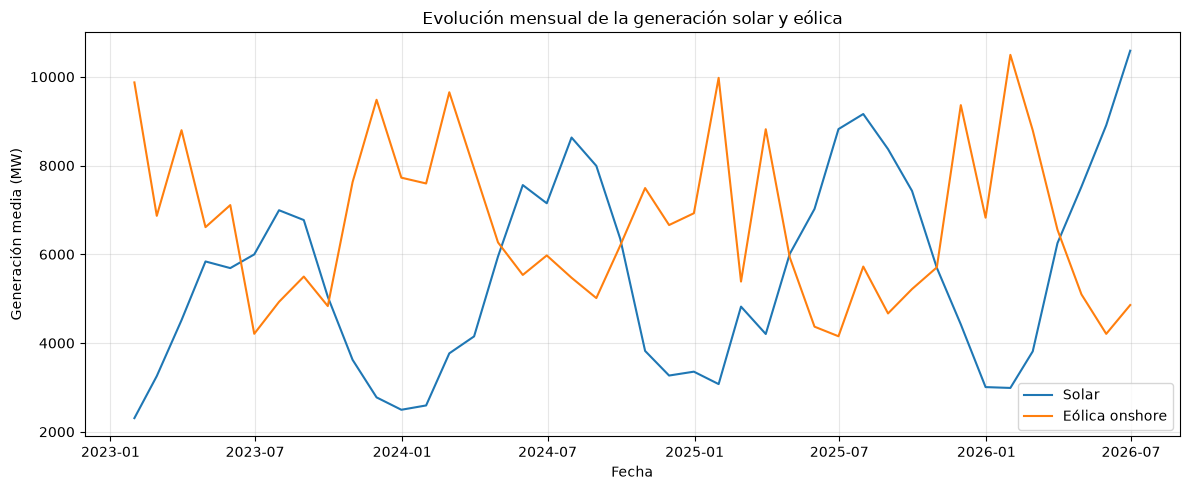

In [32]:
# Evolución mensual de la generación solar y eólica

generacion_mensual = dataset[
    ["solar_mw", "eolica_onshore_mw"]
].resample("ME").mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    generacion_mensual.index,
    generacion_mensual["solar_mw"],
    label="Solar"
)

ax.plot(
    generacion_mensual.index,
    generacion_mensual["eolica_onshore_mw"],
    label="Eólica onshore"
)

ax.set_title("Evolución mensual de la generación solar y eólica")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación media (MW)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

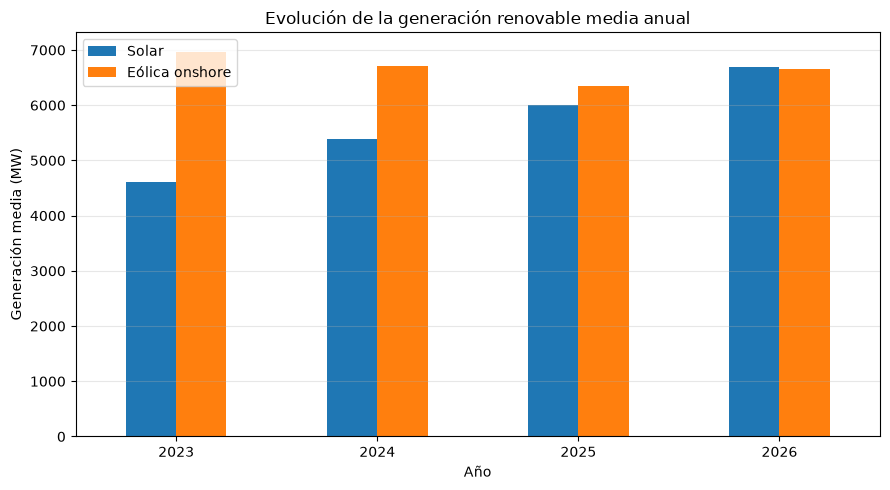

In [33]:
# Evolución de la generación media anual

generacion_anual = dataset[
    ["solar_mw", "eolica_onshore_mw"]
].groupby(dataset.index.year).mean().round(2)

ax = generacion_anual.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Evolución de la generación renovable media anual")
ax.set_xlabel("Año")
ax.set_ylabel("Generación media (MW)")
ax.legend(["Solar", "Eólica onshore"])
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La generación solar presenta una marcada estacionalidad. Sin embargo, también se observa un incremento progresivo de la generación media entre los años completos analizados: de 4.617 MW en 2023 a 5.388 MW en 2024 y 6.006 MW en 2025, lo que supone un aumento aproximado del 30 % entre 2023 y 2025.

La generación eólica muestra un comportamiento más irregular y no presenta una tendencia creciente equivalente, con medias de 6.971 MW en 2023, 6.715 MW en 2024 y 6.356 MW en 2025.

Los resultados correspondientes a 2026 deben interpretarse teniendo en cuenta que el dataset únicamente incluye el primer semestre del año.

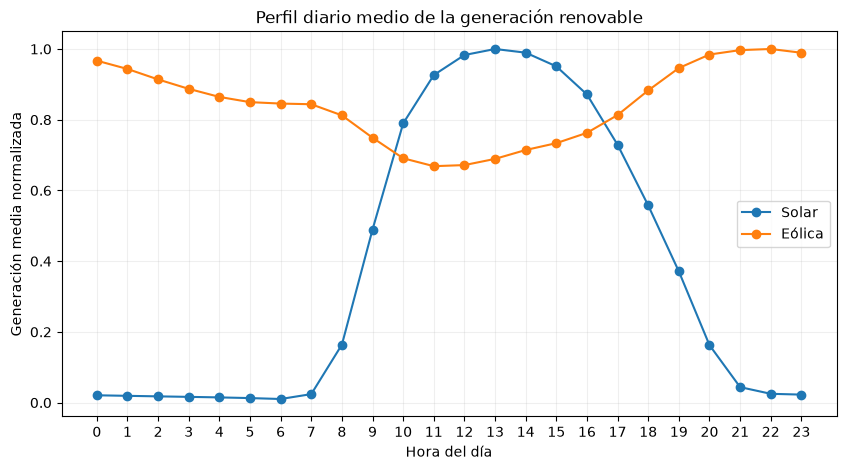

In [34]:
# Perfil medio de generación según la hora del día

perfil_horario = dataset.groupby(dataset.index.hour)[
    ["solar_mw", "eolica_onshore_mw"]
].mean()

perfil_horario_norm = perfil_horario / perfil_horario.max()

plt.figure(figsize=(10, 5))

plt.plot(
    perfil_horario_norm.index,
    perfil_horario_norm["solar_mw"],
    marker="o",
    label="Solar"
)

plt.plot(
    perfil_horario_norm.index,
    perfil_horario_norm["eolica_onshore_mw"],
    marker="o",
    label="Eólica"
)

plt.xlabel("Hora del día")
plt.ylabel("Generación media normalizada")
plt.title("Perfil diario medio de la generación renovable")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.2)

plt.show()

El perfil horario muestra una marcada estructura intradiaria en la generación solar, concentrada en las horas de radiación, mientras que la generación eólica presenta un comportamiento más estable a lo largo del día. Estos patrones respaldan la incorporación posterior de variables temporales cíclicas asociadas a la hora del día.

### 🔀 Comparación de las fuentes de radiación solar

El dataset integra dos medidas relacionadas con el recurso solar procedentes de fuentes independientes: la radiación de onda corta de Open-Meteo y la irradiancia global horizontal (GHI) de CAMS. Dado que ambas variables representan fenómenos estrechamente relacionados, se analiza su grado de asociación con el objetivo de determinar si proporcionan señales diferenciadas o presentan un elevado nivel de redundancia antes de incorporarlas a los modelos predictivos.

In [35]:
localizaciones = [
    "valencia",
    "cadiz",
    "madrid",
    "bilbao",
    "caceres",
    "tenerife",
    "zaragoza",
    "a_coruna",
    "pamplona",
    "valladolid"
]

columnas_ghi = [f"{loc}_cams_ghi" for loc in localizaciones]
columnas_radiacion = [f"{loc}_radiacion_solar" for loc in localizaciones]

ghi_medio = dataset[columnas_ghi].mean(axis=1)
radiacion_media = dataset[columnas_radiacion].mean(axis=1)

In [36]:
tabla_correlaciones = pd.DataFrame({
    "Comparación": [
        "CAMS GHI - Generación solar",
        "Open-Meteo radiación - Generación solar",
        "CAMS GHI - Open-Meteo radiación"
    ],
    "Correlación": [
        ghi_medio.corr(dataset["solar_mw"]),
        radiacion_media.corr(dataset["solar_mw"]),
        ghi_medio.corr(radiacion_media)
    ]
})

tabla_correlaciones["Correlación"] = tabla_correlaciones["Correlación"].round(3)

tabla_correlaciones

,Comparación,Correlación
0,CAMS GHI - Generación solar,0.937
1,Open-Meteo radiación - Generación solar,0.875
2,CAMS GHI - Open-Meteo radiación,0.925


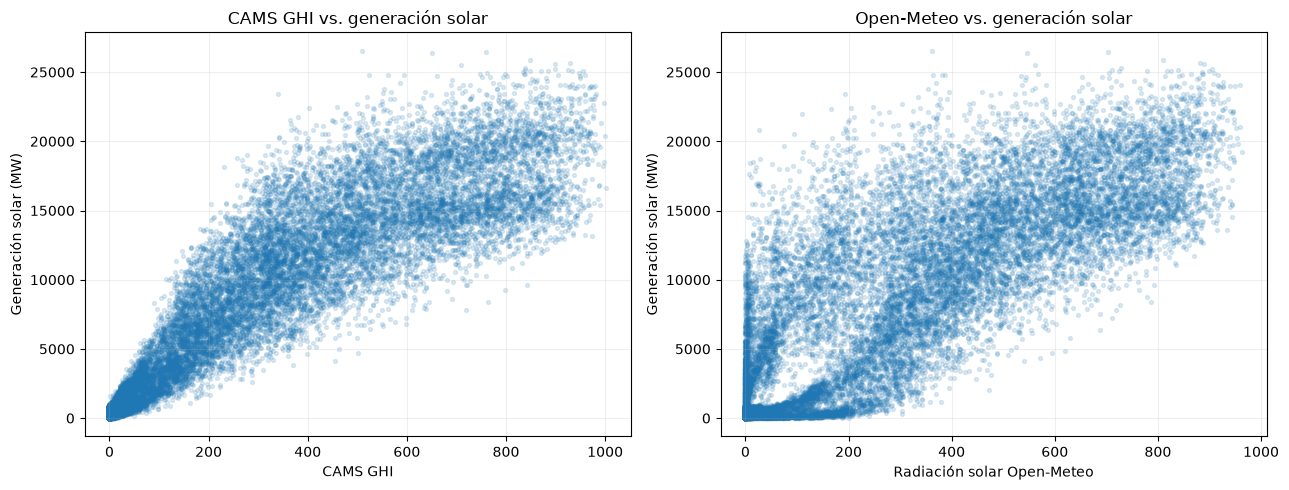

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CAMS GHI
axes[0].scatter(
    ghi_medio,
    dataset["solar_mw"],
    alpha=0.15,
    s=8
)

axes[0].set_xlabel("CAMS GHI")
axes[0].set_ylabel("Generación solar (MW)")
axes[0].set_title("CAMS GHI vs. generación solar")
axes[0].grid(alpha=0.2)

# Open-Meteo
axes[1].scatter(
    radiacion_media,
    dataset["solar_mw"],
    alpha=0.15,
    s=8
)

axes[1].set_xlabel("Radiación solar Open-Meteo")
axes[1].set_ylabel("Generación solar (MW)")
axes[1].set_title("Open-Meteo vs. generación solar")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Los resultados muestran una elevada asociación entre las dos fuentes de radiación. Sin embargo, su relación con la generación fotovoltaica presenta algunas diferencias. El GHI de CAMS alcanza una correlación de 0,937 con la generación solar, frente a 0,875 para la radiación de Open-Meteo. Por tanto, aunque existe un grado elevado de redundancia entre ambas fuentes, CAMS presenta una asociación lineal más fuerte con la variable objetivo.

### ☀️ Evolución de la relación entre irradiancia y generación solar

El incremento observado en la generación solar media puede estar relacionado tanto con diferencias en las condiciones meteorológicas como con cambios estructurales del sistema eléctrico durante el periodo analizado. Para explorar esta cuestión, se compara la generación fotovoltaica asociada a niveles similares de irradiancia global horizontal (GHI) en los distintos años.

La irradiancia se agrupa en intervalos para reducir la variabilidad horaria y facilitar la comparación de la relación entre GHI y generación solar a lo largo del tiempo.

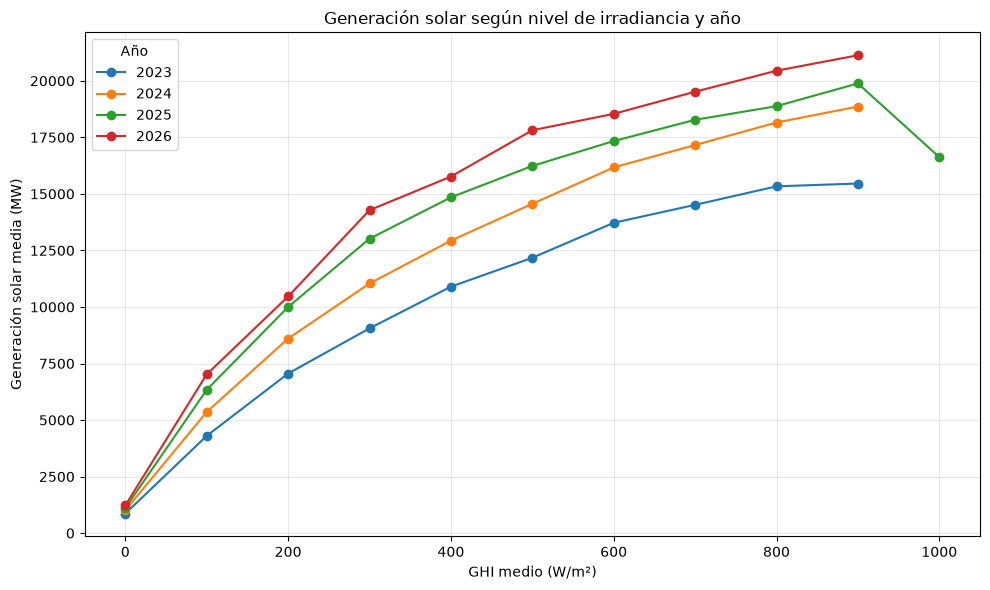

In [38]:
# Relación entre GHI y generación solar por año

analisis_solar = pd.DataFrame({
    "ghi_medio": ghi_medio,
    "solar_mw": dataset["solar_mw"],
    "año": dataset.index.year
})

# Excluimos las horas sin irradiancia
analisis_solar = analisis_solar[analisis_solar["ghi_medio"] > 0]

# Agrupamos la irradiancia en intervalos de 100 W/m²
analisis_solar["rango_ghi"] = (
    analisis_solar["ghi_medio"] // 100 * 100
)

solar_por_ghi = (
    analisis_solar
    .groupby(["año", "rango_ghi"])["solar_mw"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for año in sorted(solar_por_ghi["año"].unique()):
    datos_año = solar_por_ghi[solar_por_ghi["año"] == año]

    ax.plot(
        datos_año["rango_ghi"],
        datos_año["solar_mw"],
        marker="o",
        label=str(año)
    )

ax.set_title("Generación solar según nivel de irradiancia y año")
ax.set_xlabel("GHI medio (W/m²)")
ax.set_ylabel("Generación solar media (MW)")
ax.legend(title="Año")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La comparación por años muestra que la relación entre irradiancia y generación solar no permanece estable durante el periodo analizado. Para niveles similares de GHI, la generación fotovoltaica registrada es sistemáticamente superior en los años más recientes, especialmente al comparar 2023 con 2024, 2025 y 2026.

Este patrón indica que las diferencias observadas en la generación solar a lo largo del periodo no pueden explicarse únicamente por variaciones en la irradiancia. Existen, por tanto, factores temporales o estructurales adicionales que afectan a la relación entre recurso solar y generación eléctrica.

Este resultado será relevante en la fase de feature engineering, ya que sugiere la conveniencia de incorporar información temporal al modelo para capturar la evolución de esta relación. 

Los resultados correspondientes a 2026 deben interpretarse teniendo en cuenta que el dataset únicamente incluye el primer semestre del año.

### 🌬️ Variables de viento y generación eólica

Se analiza la relación entre las principales medidas de intensidad del viento y la generación eólica *onshore*. Para obtener una aproximación de las condiciones meteorológicas a nivel nacional, se calcula el promedio horario de cada variable entre las diez localizaciones seleccionadas y posteriormente su correlación con la generación eólica.

In [39]:
# Comparación de las principales variables de viento

localizaciones = [
    "valencia",
    "cadiz",
    "madrid",
    "bilbao",
    "caceres",
    "tenerife",
    "zaragoza",
    "a_coruna",
    "pamplona",
    "valladolid"
]

columnas_viento_10m = [
    f"{loc}_viento_10m" for loc in localizaciones
]

columnas_viento_100m = [
    f"{loc}_viento_100m" for loc in localizaciones
]

columnas_rachas_10m = [
    f"{loc}_rachas_viento_10m" for loc in localizaciones
]

viento_10m_medio = dataset[columnas_viento_10m].mean(axis=1)
viento_100m_medio = dataset[columnas_viento_100m].mean(axis=1)
rachas_10m_medio = dataset[columnas_rachas_10m].mean(axis=1)

tabla_viento = pd.DataFrame({
    "Variable": [
        "Viento medio 10 m",
        "Viento medio 100 m",
        "Rachas medias 10 m"
    ],
    "Correlación con generación eólica": [
        viento_10m_medio.corr(dataset["eolica_onshore_mw"]),
        viento_100m_medio.corr(dataset["eolica_onshore_mw"]),
        rachas_10m_medio.corr(dataset["eolica_onshore_mw"])
    ]
})

tabla_viento["Correlación con generación eólica"] = (
    tabla_viento["Correlación con generación eólica"].round(3)
)

tabla_viento

,Variable,Correlación con generación eólica
0,Viento medio 10 m,0.704
1,Viento medio 100 m,0.844
2,Rachas medias 10 m,0.563


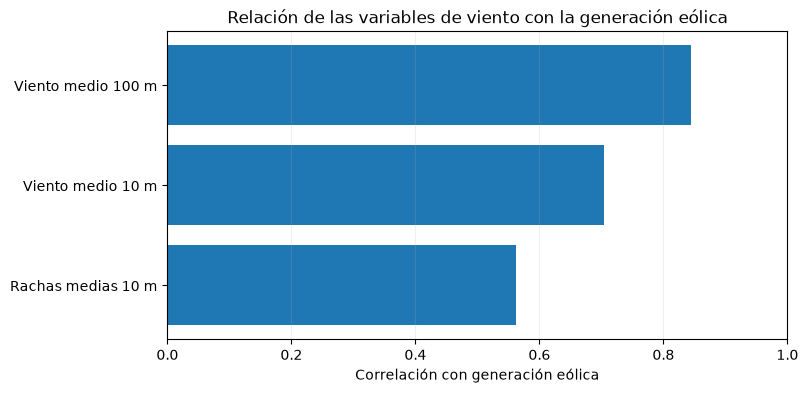

In [40]:
plt.figure(figsize=(8, 4))

tabla_viento_ordenada = tabla_viento.sort_values(
    "Correlación con generación eólica",
    ascending=True
)

plt.barh(
    tabla_viento_ordenada["Variable"],
    tabla_viento_ordenada["Correlación con generación eólica"]
)

plt.xlabel("Correlación con generación eólica")
plt.title("Relación de las variables de viento con la generación eólica")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.2)

plt.show()

Los resultados muestran que la velocidad media del viento a 100 metros presenta la mayor asociación con la generación eólica onshore, con una correlación de 0,844, frente a 0,704 para la velocidad a 10 metros y 0,563 para las ráfagas a 10 metros. Esto indica que la información del viento a mayor altura resulta especialmente relevante para explicar las variaciones en la generación eólica. Las ráfagas, aunque mantienen una relación positiva con la producción, presentan una asociación considerablemente menor. En conjunto, estos resultados respaldan la incorporación de las distintas variables de viento en la fase de modelado, prestando especial atención a la velocidad registrada a 100 metros.

### 📍 Representatividad de las localizaciones meteorológicas

El dataset incorpora información meteorológica de diez localizaciones distribuidas por distintas zonas de España. Dado que las variables objetivo representan la generación agregada a nivel nacional, resulta relevante analizar si las señales meteorológicas de todas las localizaciones presentan el mismo grado de asociación con la generación renovable.

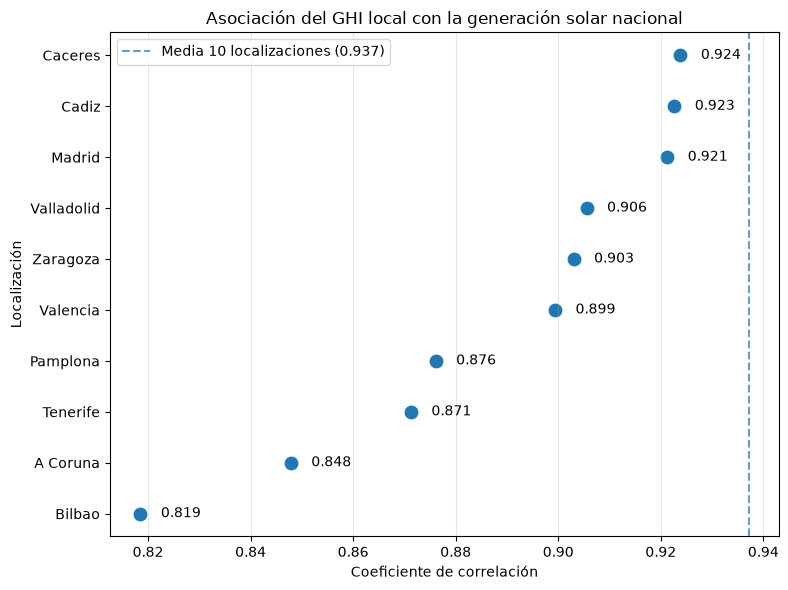

In [41]:
# Representatividad de las localizaciones para la generación solar

correlaciones_solar_localizacion = pd.Series({
    loc.replace("_", " ").title(): dataset[f"{loc}_cams_ghi"].corr(dataset["solar_mw"])
    for loc in localizaciones
}).sort_values()

# Correlación del GHI medio de las diez localizaciones
corr_ghi_medio = ghi_medio.corr(dataset["solar_mw"])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    correlaciones_solar_localizacion.values,
    correlaciones_solar_localizacion.index,
    s=80
)

for ciudad, valor in correlaciones_solar_localizacion.items():
    ax.text(
        valor + 0.004,
        ciudad,
        f"{valor:.3f}",
        va="center"
    )

ax.axvline(
    corr_ghi_medio,
    linestyle="--",
    alpha=0.7,
    label=f"Media 10 localizaciones ({corr_ghi_medio:.3f})"
)

ax.set_title("Asociación del GHI local con la generación solar nacional")
ax.set_xlabel("Coeficiente de correlación")
ax.set_ylabel("Localización")
ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Las diez localizaciones presentan una asociación elevada con la generación solar nacional, aunque existen diferencias en su representatividad. Cáceres (0,924), Cádiz (0,923) y Madrid (0,921) muestran las correlaciones individuales más elevadas, mientras que Bilbao presenta la menor (0,819).

La agregación de la información espacial mejora la asociación con la generación nacional: el GHI medio de las diez localizaciones alcanza una correlación de 0,937, superior a la obtenida por cualquiera de las localizaciones de forma individual. Este resultado respalda la utilización conjunta de información meteorológica procedente de distintas zonas geográficas para representar las condiciones solares a escala nacional.

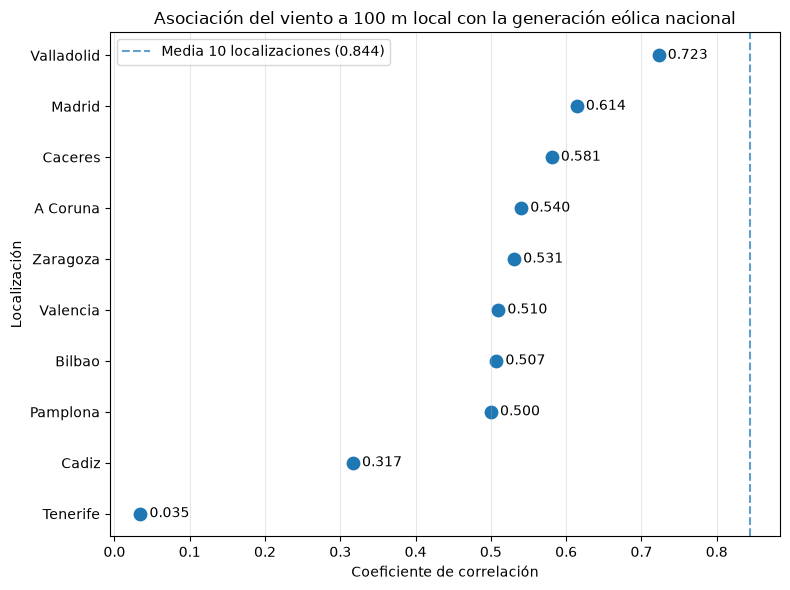

In [42]:
# Representatividad de las localizaciones para la generación eólica

correlaciones_eolica_localizacion = pd.Series({
    loc.replace("_", " ").title(): dataset[f"{loc}_viento_100m"].corr(
        dataset["eolica_onshore_mw"]
    )
    for loc in localizaciones
}).sort_values()

# Correlación del viento medio de las diez localizaciones
corr_viento_medio = viento_100m_medio.corr(
    dataset["eolica_onshore_mw"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    correlaciones_eolica_localizacion.values,
    correlaciones_eolica_localizacion.index,
    s=80
)

for ciudad, valor in correlaciones_eolica_localizacion.items():
    ax.text(
        valor + 0.012,
        ciudad,
        f"{valor:.3f}",
        va="center"
    )

ax.axvline(
    corr_viento_medio,
    linestyle="--",
    alpha=0.7,
    label=f"Media 10 localizaciones ({corr_viento_medio:.3f})"
)

ax.set_title("Asociación del viento a 100 m local con la generación eólica nacional")
ax.set_xlabel("Coeficiente de correlación")
ax.set_ylabel("Localización")
ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

En el caso de la generación eólica se observan diferencias espaciales considerablemente mayores. Valladolid presenta la mayor correlación individual con la generación eólica nacional (0,723), seguida de Madrid (0,614) y Cáceres (0,581), mientras que otras localizaciones muestran asociaciones mucho más reducidas, especialmente Cádiz (0,317) y Tenerife (0,035).

Sin embargo, al agregar la velocidad del viento a 100 metros de las diez localizaciones, la correlación con la generación eólica nacional aumenta hasta 0,844, superando ampliamente la obtenida por cualquier localización de forma individual. Este resultado pone de manifiesto la importancia de incorporar información procedente de distintas zonas geográficas para representar un fenómeno agregado a escala nacional y respalda la utilización conjunta de las variables meteorológicas de las distintas localizaciones durante el modelado.

### 🔗 Relación entre generación solar-eólica, demanda y precio de la electricidad

Además de analizar los factores meteorológicos asociados con la generación renovable, resulta relevante contextualizar la producción solar y eólica dentro del sistema eléctrico.

Para ello, se construye un indicador de **cobertura solar-eólica**, definido como la proporción de la demanda eléctrica horaria cubierta conjuntamente por la generación solar fotovoltaica y eólica onshore. 

In [43]:
# Comprobación de valores anómalos en la demanda

demanda_cero = dataset[dataset["total_load_mw"] == 0]

print("Observaciones con demanda igual a 0:", len(demanda_cero))

demanda_cero[
    ["solar_mw", "eolica_onshore_mw", "total_load_mw", "precio_eur_mwh"]
]

Observaciones con demanda igual a 0: 1


,solar_mw,eolica_onshore_mw,total_load_mw,precio_eur_mwh
2026-03-17 12:00:00+01:00,19221.0,1920.0,0.0,-0.96


Se identifica una única observación con demanda igual a 0 MW. Este valor impediría calcular correctamente el cociente entre generación y demanda al implicar una división entre cero. Por este motivo, para el cálculo inicial del indicador se sustituye temporalmente por un valor nulo, manteniendo intacta la información original del dataset.

La posible naturaleza anómala de esta observación se analizará posteriormente mediante la inspección de los valores extremos obtenidos.

El indicador se calcula como la suma de la generación solar fotovoltaica y eólica onshore dividida entre la demanda eléctrica total registrada en la misma hora:

**Cobertura solar-eólica (%) = (Generación solar + Generación eólica) / Demanda × 100**

In [44]:
# Ratio de generación solar y eólica respecto a la demanda

generacion_renovable = (
    dataset["solar_mw"] +
    dataset["eolica_onshore_mw"]
)

penetracion_renovable = (
    generacion_renovable /
    dataset["total_load_mw"].replace(0, np.nan)
) * 100

penetracion_renovable.describe().round(2)

count    30604.00
mean        45.56
std         23.58
min          1.61
25%         25.38
50%         43.96
75%         65.06
max        295.65
dtype: float64

El indicador presenta una media del 45,56 % y una mediana del 43,96 %, lo que indica que la generación conjunta solar y eólica representa una proporción considerable de la demanda durante el periodo analizado. Al mismo tiempo, se observa una elevada variabilidad, con valores que oscilan entre aproximadamente el 1,6 % y el 295,7 %. La existencia de un máximo muy superior al 100 % hace necesario analizar la distribución completa del indicador e inspeccionar las observaciones extremas para determinar si responden a situaciones plausibles del sistema eléctrico o a posibles anomalías en los datos.

#### Distribución de la cobertura solar-eólica sobre la demanda

A continuación, se analiza la distribución del indicador con el objetivo de identificar cuáles son los niveles de cobertura más frecuentes y detectar posibles valores extremos.

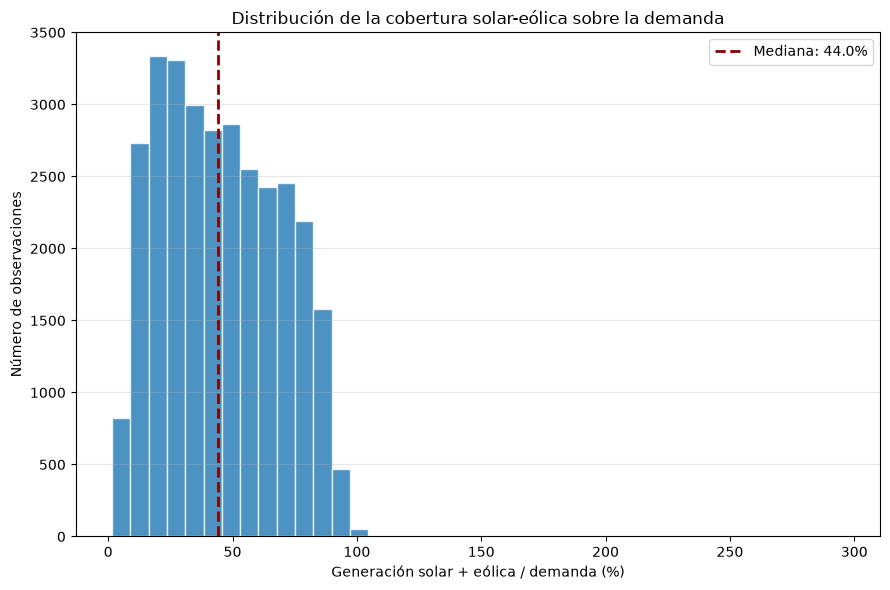

In [45]:
# Distribución de la cobertura solar-eólica sobre la demanda

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    penetracion_renovable.dropna(),
    bins=40,
    edgecolor="white",
    alpha=0.8
)

ax.axvline(
    penetracion_renovable.median(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {penetracion_renovable.median():.1f}%"
)

ax.set_title("Distribución de la cobertura solar-eólica sobre la demanda")
ax.set_xlabel("Generación solar + eólica / demanda (%)")
ax.set_ylabel("Número de observaciones")

ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

La distribución muestra una variabilidad considerable en la cobertura solar-eólica a lo largo del periodo analizado. La mediana se sitúa aproximadamente en el 44 %, indicando que en la mitad de las observaciones la generación conjunta solar y eólica cubre menos de este porcentaje de la demanda eléctrica, mientras que en la otra mitad lo supera.

La gran mayoría de las observaciones se concentra por debajo del 100 %, aunque existen algunos episodios en los que el indicador supera este nivel. Estos valores no deben considerarse automáticamente anómalos, por lo que resulta necesario inspeccionar especialmente el máximo observado.


#### Inspección de valores extremos de cobertura solar-eólica

Dado que la distribución anterior muestra algunas observaciones superiores al 100 % y un máximo especialmente elevado, se inspecciona la observación con mayor nivel de cobertura y la evolución de las principales variables eléctricas durante las horas inmediatamente anteriores y posteriores.

In [46]:
# Observación con el mayor nivel de cobertura solar-eólica

idx_max = penetracion_renovable.idxmax()

dataset.loc[
    idx_max,
    ["solar_mw", "eolica_onshore_mw", "total_load_mw", "precio_eur_mwh"]
]

solar_mw             17375.00
eolica_onshore_mw     1987.00
total_load_mw         6549.00
precio_eur_mwh          -0.76
Name: 2026-03-17 11:00:00+01:00, dtype: float64

In [47]:
# Comprobar la demanda alrededor de la observación extrema

dataset.loc[
    "2026-03-17 06:00":"2026-03-17 16:00",
    ["solar_mw", "eolica_onshore_mw", "total_load_mw", "precio_eur_mwh"]
]

,solar_mw,eolica_onshore_mw,total_load_mw,precio_eur_mwh
2026-03-17 06:00:00+01:00,34.0,4701.0,26650.0,66.43
2026-03-17 07:00:00+01:00,770.0,4902.0,30172.0,107.88
2026-03-17 08:00:00+01:00,9615.0,4470.0,31029.0,46.06
2026-03-17 09:00:00+01:00,18540.0,3093.0,29788.0,2.20
2026-03-17 10:00:00+01:00,19608.0,2402.0,21253.0,-0.13
2026-03-17 11:00:00+01:00,17375.0,1987.0,6549.0,-0.76
2026-03-17 12:00:00+01:00,19221.0,1920.0,0.0,-0.96
2026-03-17 13:00:00+01:00,18989.0,1746.0,19538.0,-1.12
2026-03-17 14:00:00+01:00,19266.0,1803.0,26097.0,-1.37
2026-03-17 15:00:00+01:00,18883.0,1889.0,25986.0,-0.96


La inspección del episodio extremo muestra un comportamiento anómalo en la serie de demanda de ENTSO-E. El 17 de marzo de 2026, la demanda pasa de 29.788 MW a las 09:00 a 21.253 MW a las 10:00 y posteriormente desciende hasta 6.549 MW a las 11:00 y 0 MW a las 12:00. En la hora siguiente vuelve a situarse en 19.538 MW y posteriormente recupera niveles superiores a 25.000 MW.

Esta caída abrupta y temporal de la demanda explica el máximo del 295,65 % obtenido en el indicador de cobertura solar-eólica y sugiere la existencia de una anomalía puntual en los datos de demanda. Estas observaciones deberán ser tratadas durante la fase de preprocesamiento previa al modelado para evitar que generen valores artificialmente elevados en las variables derivadas.

Este resultado no implica, sin embargo, que todos los valores superiores al 100 % sean incorrectos. Excluyendo el episodio extremo de 295,65 %, existen algunas horas con ratios ligeramente superiores al 100 % que pueden corresponder a situaciones plausibles de elevada generación solar y eólica respecto a la demanda registrada.

### 🔥 Visión conjunta de las principales relaciones

Como cierre del análisis exploratorio, se examinan conjuntamente las correlaciones lineales entre las principales variables energéticas y meteorológicas del proyecto. Para facilitar la interpretación, se utilizan los valores medios de las diez localizaciones para aquellas variables meteorológicas que disponen de información geográfica.

La matriz permite sintetizar las relaciones identificadas a lo largo del análisis, incorporando las principales señales asociadas a la generación solar y eólica, así como la demanda y el precio de la electricidad.


In [48]:
# Transformación de la dirección del viento mediante componentes circulares

# Dirección a 10 m
columnas_dir_10m = [
    f"{loc}_direccion_viento_10m" for loc in localizaciones
]

dir_10m_rad = np.radians(dataset[columnas_dir_10m])

direccion_10m_sin = np.sin(dir_10m_rad).mean(axis=1)
direccion_10m_cos = np.cos(dir_10m_rad).mean(axis=1)


# Dirección a 100 m
columnas_dir_100m = [
    f"{loc}_direccion_viento_100m" for loc in localizaciones
]

dir_100m_rad = np.radians(dataset[columnas_dir_100m])

direccion_100m_sin = np.sin(dir_100m_rad).mean(axis=1)
direccion_100m_cos = np.cos(dir_100m_rad).mean(axis=1)

In [49]:
# Variables meteorológicas medias de las 10 localizaciones

viento_10m_medio = dataset[
    [f"{loc}_viento_10m" for loc in localizaciones]
].mean(axis=1)

rachas_10m_medio = dataset[
    [f"{loc}_rachas_viento_10m" for loc in localizaciones]
].mean(axis=1)

radiacion_media = dataset[
    [f"{loc}_radiacion_solar" for loc in localizaciones]
].mean(axis=1)

nubes_medio = dataset[
    [f"{loc}_nubes_pct" for loc in localizaciones]
].mean(axis=1)

temperatura_media = dataset[
    [f"{loc}_temperatura" for loc in localizaciones]
].mean(axis=1)

presion_media = dataset[
    [f"{loc}_presion" for loc in localizaciones]
].mean(axis=1)


# Correlaciones entre las principales variables del sistema

correlaciones_globales = pd.DataFrame({
    "Generación solar": dataset["solar_mw"],
    "Generación eólica": dataset["eolica_onshore_mw"],
    "Demanda": dataset["total_load_mw"],
    "Precio": dataset["precio_eur_mwh"],
    "GHI CAMS": ghi_medio,
    "Radiación": radiacion_media,
    "Nubosidad": nubes_medio,
    "Viento 10 m": viento_10m_medio,
    "Viento 100 m": viento_100m_medio,
    "Ráfagas 10 m": rachas_10m_medio,
    "Dir. 10 m (sin)": direccion_10m_sin,
    "Dir. 10 m (cos)": direccion_10m_cos,
    "Dir. 100 m (sin)": direccion_100m_sin,
    "Dir. 100 m (cos)": direccion_100m_cos,
    "Temperatura": temperatura_media,
    "Presión": presion_media
}).corr()

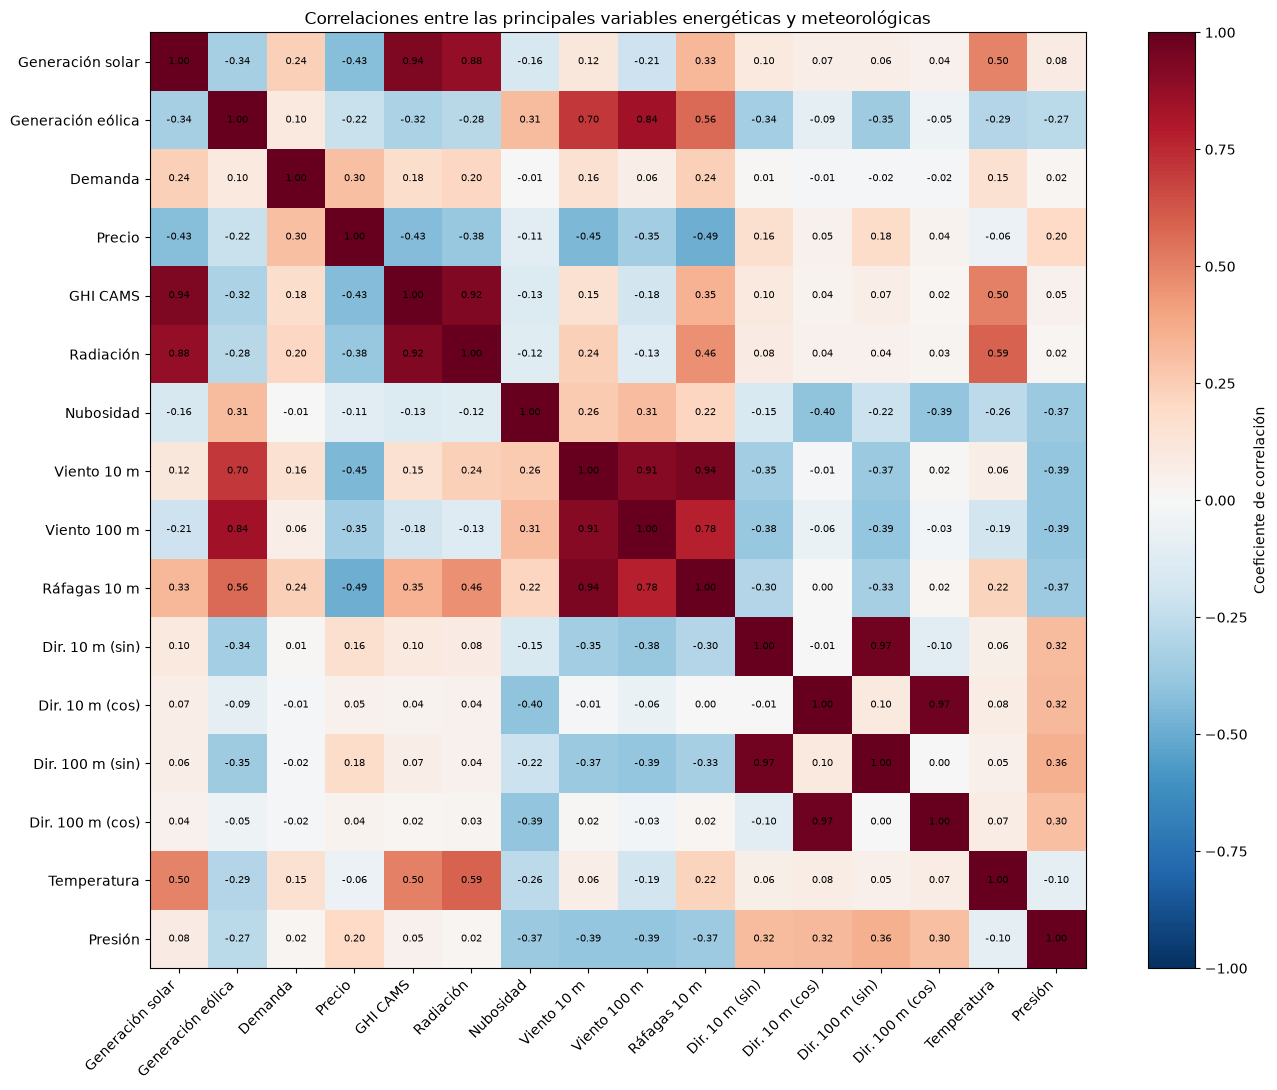

In [50]:
# Mapa de correlaciones entre las principales variables

fig, ax = plt.subplots(figsize=(14, 11))

im = ax.imshow(
    correlaciones_globales,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r"
)

ax.set_xticks(range(len(correlaciones_globales.columns)))
ax.set_yticks(range(len(correlaciones_globales.columns)))

ax.set_xticklabels(
    correlaciones_globales.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlaciones_globales.columns)

# Mostrar el valor de cada correlación
for i in range(len(correlaciones_globales)):
    for j in range(len(correlaciones_globales)):
        ax.text(
            j,
            i,
            f"{correlaciones_globales.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.colorbar(im, label="Coeficiente de correlación")

ax.set_title(
    "Correlaciones entre las principales variables energéticas y meteorológicas"
)

plt.tight_layout()
plt.show()

La matriz de correlaciones permite sintetizar las principales relaciones identificadas durante el análisis exploratorio. En el caso de la generación solar, las asociaciones más elevadas se observan con el GHI de CAMS (0,94) y la radiación solar de Open-Meteo (0,88), confirmando la estrecha relación entre la disponibilidad de radiación y la producción fotovoltaica. Ambas variables presentan, además, una correlación elevada entre sí (0,92), lo que indica que contienen información parcialmente redundante.

Para la generación eólica, la velocidad del viento a 100 m presenta la asociación más elevada (0,84), seguida del viento a 10 m (0,70) y las ráfagas a 10 m (0,56). Las componentes seno de la dirección del viento muestran también cierta asociación con la generación eólica (-0,34 a 10 m y -0,35 a 100 m), mientras que las componentes coseno presentan relaciones lineales débiles. La elevada correlación entre algunas variables eólicas, especialmente entre el viento a 10 m y 100 m (0,91) y entre el viento a 10 m y las ráfagas (0,94), evidencia igualmente la existencia de información compartida entre predictores.

Por otra parte, el precio mayorista presenta una asociación negativa tanto con la generación solar (-0,43) como con la eólica (-0,22). La demanda muestra relaciones lineales más reducidas con las variables meteorológicas. No obstante, esto no implica necesariamente una ausencia de relación.

En conjunto, el análisis confirma la relevancia de las variables meteorológicas seleccionadas para la predicción de la generación solar y eólica, al mismo tiempo que pone de manifiesto correlaciones elevadas entre algunos predictores. Por este motivo, en la fase de modelado no se realizará una selección de variables basada únicamente en correlaciones lineales, sino que se compararán distintos algoritmos capaces de capturar relaciones no lineales e interacciones entre variables. Posteriormente, se analizará la contribución de los diferentes predictores mediante técnicas de interpretabilidad del modelo.

## ⚙️ Preprocesamiento y Feature Engineering

En esta sección se preparan los datos para el entrenamiento de los modelos de predicción de generación solar y eólica. A partir de las variables originales se incorporan nuevas características temporales y físicas con el objetivo de representar patrones relevantes identificados durante el análisis exploratorio, evitando al mismo tiempo variables redundantes o que puedan introducir *data leakage*.

#### 🕣 Variables temporales

Se incorporan variables asociadas a la hora del día y al mes del año para representar los patrones diarios y estacionales observados en la generación renovable. Además, se utiliza una codificación cíclica mediante seno y coseno para reflejar la naturaleza periódica de estas variables.

In [51]:
# Hora del día y mes del año
dataset["hora"] = dataset.index.hour
dataset["mes"] = dataset.index.month

# Codificación cíclica de la hora
dataset["hora_sin"] = np.sin(2 * np.pi * dataset["hora"] / 24)
dataset["hora_cos"] = np.cos(2 * np.pi * dataset["hora"] / 24)

# Codificación cíclica del mes
dataset["mes_sin"] = np.sin(2 * np.pi * (dataset["mes"] - 1) / 12)
dataset["mes_cos"] = np.cos(2 * np.pi * (dataset["mes"] - 1) / 12)

#### 🕞 Variables históricas de generación

Se incorporan variables lag de 24 horas para representar la dependencia temporal de la generación renovable. Para cada tecnología se utiliza la generación registrada 24 horas antes, permitiendo incorporar información sobre el patrón diario reciente de la producción. Estas variables se construyen mediante valores desplazados temporalmente, de modo que cada observación utiliza exclusivamente información correspondiente a un instante anterior y no el valor de generación que se pretende predecir. Por tanto, su construcción no introduce por sí misma data leakage.

Se utiliza un retardo de 24 horas por ser coherente con el horizonte de predicción planteado en RenewAI. Aunque un lag de una hora puede proporcionar una elevada capacidad predictiva debido a la persistencia temporal de las series de generación, requeriría disponer de la generación inmediatamente anterior y estaría orientado a predicciones de muy corto plazo. Por este motivo, se excluye del modelado final.

In [52]:
# Variables lag de generación

dataset["solar_lag_24h"] = dataset["solar_mw"].shift(24)

dataset["eolica_lag_24h"] = dataset["eolica_onshore_mw"].shift(24)

#### 🎐 Variables derivadas para la generación eólica

A partir de las variables meteorológicas originales se generan nuevas características destinadas a representar mejor algunas propiedades físicas del viento relevantes para la generación eólica.

En primer lugar, se incorpora para cada localización el cubo de la velocidad del viento a 100 metros de altura. Esta transformación se basa en la relación aproximadamente cúbica entre la velocidad del viento y la potencia disponible, y permite representar de forma explícita una relación no lineal que también se ha observado durante el análisis exploratorio.

Por otra parte, la dirección del viento, disponible a 10 y 100 metros, se transforma mediante componentes seno y coseno. Al tratarse de una variable circular, esta codificación evita la discontinuidad existente entre valores próximos como 359° y 0° y permite incorporar adecuadamente la información direccional en los modelos predictivos.

In [53]:
localizaciones = [
    "valencia",
    "cadiz",
    "madrid",
    "bilbao",
    "caceres",
    "tenerife",
    "zaragoza",
    "a_coruna",
    "pamplona",
    "valladolid"
]

In [54]:
# Variable cúbica de la velocidad del viento a 100 m

for loc in localizaciones:
    dataset[f"{loc}_viento_100m_cubo"] = (
        dataset[f"{loc}_viento_100m"] ** 3
    )

In [55]:
# Variables derivadas de la dirección del viento

for loc in localizaciones:

    # Dirección del viento a 10 m
    direccion_10m_rad = np.deg2rad(
        dataset[f"{loc}_direccion_viento_10m"]
    )

    dataset[f"{loc}_direccion_viento_10m_sin"] = np.sin(direccion_10m_rad)
    dataset[f"{loc}_direccion_viento_10m_cos"] = np.cos(direccion_10m_rad)

    # Dirección del viento a 100 m
    direccion_100m_rad = np.deg2rad(
        dataset[f"{loc}_direccion_viento_100m"]
    )

    dataset[f"{loc}_direccion_viento_100m_sin"] = np.sin(direccion_100m_rad)
    dataset[f"{loc}_direccion_viento_100m_cos"] = np.cos(direccion_100m_rad)

#### 🌅 Variables derivadas para la generación solar

La generación solar depende principalmente de la radiación disponible, aunque las condiciones de nubosidad pueden modificar significativamente su aprovechamiento. Por ello, se crea para cada localización una variable que combina la radiación solar de Open-Meteo con el porcentaje de nubosidad, multiplicando la radiación por la fracción de cielo no cubierta por nubes. Esta variable constituye una aproximación simplificada de las condiciones solares efectivas y se incorpora como característica adicional junto con las variables originales de radiación, nubosidad y GHI de CAMS.

In [56]:
for loc in localizaciones:
    dataset[f"{loc}_solar_efectiva"] = (
        dataset[f"{loc}_radiacion_solar"]
        * (1 - dataset[f"{loc}_nubes_pct"] / 100)
    )

#### 📉 Valores anómalos de la demanda

Durante el análisis exploratorio se identificaron dos observaciones anómalas consecutivas en la demanda eléctrica, con valores de 6.549 MW y 0 MW, claramente alejados del comportamiento de las horas adyacentes. Para evitar que estas observaciones distorsionen los indicadores derivados de la demanda, ambos valores se sustituyen mediante interpolación temporal, manteniendo intactas el resto de variables correspondientes a dichas horas.

In [57]:
# Tratamiento de valores anómalos en la demanda

fechas_anomalas = [
    "2026-03-17 11:00:00+01:00",
    "2026-03-17 12:00:00+01:00"
]

# Los valores anómalos se consideran temporalmente ausentes
dataset.loc[fechas_anomalas, "total_load_mw"] = np.nan

# Interpolación temporal utilizando las horas adyacentes
dataset["total_load_mw"] = dataset["total_load_mw"].interpolate(method="time")

In [58]:
# Comprobación final de la calidad de los datos

print("Dimensiones del dataset:", dataset.shape)
print("Valores nulos:", dataset.isna().sum().sum())
print("Filas duplicadas:", dataset.duplicated().sum())
print("Índice temporal ordenado:", dataset.index.is_monotonic_increasing)

Dimensiones del dataset: (30605, 172)
Valores nulos: 48
Filas duplicadas: 0
Índice temporal ordenado: True


#### 📶 Cobertura solar-eólica

Además de las variables destinadas directamente a la predicción de la generación renovable, se incorpora al conjunto de datos la variable **cobertura_renovable**, construida a partir del indicador analizado durante el EDA. Esta variable relaciona la generación conjunta solar y eólica con la demanda eléctrica registrada en cada hora.

Este indicador no se utiliza como variable predictora de los modelos de generación, ya que incorpora directamente las variables objetivo y podría introducir data leakage. Su finalidad es proporcionar una medida interpretable de la contribución de ambas tecnologías a la cobertura de la demanda y servir posteriormente como indicador de monitorización en la aplicación.

La cobertura se calcula como:

Cobertura solar-eólica (%) = (Generación solar + Generación eólica) / Demanda × 100

In [59]:
# Cobertura solar-eólica

dataset["cobertura_renovable"] = (
    (dataset["solar_mw"] + dataset["eolica_onshore_mw"])
    / dataset["total_load_mw"]
) * 100


## 📋 Preparación para el modelado

#### ✅ Selección de variables para los modelos predictivos

A partir de las variables disponibles y de los resultados obtenidos durante el análisis exploratorio, se definen conjuntos de predictores específicos para los modelos de generación solar y eólica. La selección combina variables meteorológicas, temporales, físicas derivadas e información histórica de la propia generación.

In [60]:
# Localizaciones consideradas
localizaciones = [
    "valencia",
    "cadiz",
    "madrid",
    "bilbao",
    "caceres",
    "tenerife",
    "zaragoza",
    "a_coruna",
    "pamplona",
    "valladolid"
]

# Variables temporales
variables_temporales = [
    "hora_sin", "hora_cos",
    "mes_sin", "mes_cos"
]


# MODELO SOLAR

features_solar = (
    [f"{loc}_cams_ghi" for loc in localizaciones] +
    [f"{loc}_radiacion_solar" for loc in localizaciones] +
    [f"{loc}_nubes_pct" for loc in localizaciones] +
    [f"{loc}_temperatura" for loc in localizaciones] +
    [f"{loc}_solar_efectiva" for loc in localizaciones] +
    variables_temporales +
    ["solar_lag_24h"]
)


# MODELO EÓLICO

features_eolica = (
    [f"{loc}_viento_10m" for loc in localizaciones] +
    [f"{loc}_viento_100m" for loc in localizaciones] +
    [f"{loc}_rachas_viento_10m" for loc in localizaciones] +
    [f"{loc}_viento_100m_cubo" for loc in localizaciones] +
    
    [f"{loc}_direccion_viento_10m_sin" for loc in localizaciones] +
    [f"{loc}_direccion_viento_10m_cos" for loc in localizaciones] +
    [f"{loc}_direccion_viento_100m_sin" for loc in localizaciones] +
    [f"{loc}_direccion_viento_100m_cos" for loc in localizaciones] +
    
    [f"{loc}_temperatura" for loc in localizaciones] +
    [f"{loc}_presion" for loc in localizaciones] +
    [f"{loc}_nubes_pct" for loc in localizaciones] +
    
    variables_temporales +
    ["eolica_lag_24h"]
)

print("Variables modelo solar:", len(features_solar))
print("Variables modelo eólico:", len(features_eolica))

Variables modelo solar: 55
Variables modelo eólico: 115


#### 🔃 Split Train/Test

Dado el carácter temporal de los datos, la división se realiza respetando estrictamente el orden cronológico de las observaciones. Se establecen tres subconjuntos independientes: entrenamiento, validación y prueba. El conjunto de entrenamiento comprende desde enero de 2023 hasta diciembre de 2024; el conjunto de validación abarca de enero a junio de 2025 y se utiliza para comparar modelos y configuraciones; finalmente, el conjunto de test comprende de julio de 2025 a junio de 2026 y se reserva para la evaluación final sobre observaciones futuras no utilizadas durante el proceso de selección.

In [61]:
dataset = dataset.dropna(
    subset=[
        "solar_lag_24h",
        "eolica_lag_24h"
    ]
)

print("Dimensiones del dataset:", dataset.shape)

print("\nValores nulos en los lags:")
print(
    dataset[
        ["solar_lag_24h", "eolica_lag_24h"]
    ].isna().sum()
)

Dimensiones del dataset: (30581, 173)

Valores nulos en los lags:
solar_lag_24h     0
eolica_lag_24h    0
dtype: int64


In [62]:
X_solar = dataset[features_solar]
y_solar = dataset["solar_mw"]

X_eolica = dataset[features_eolica]
y_eolica = dataset["eolica_onshore_mw"]

print("X_solar:", X_solar.shape)
print("y_solar:", y_solar.shape)

print("\nX_eolica:", X_eolica.shape)
print("y_eolica:", y_eolica.shape)

X_solar: (30581, 55)
y_solar: (30581,)

X_eolica: (30581, 115)
y_eolica: (30581,)


In [63]:
# Fechas de separación
fecha_inicio_validacion = "2025-01-01"
fecha_inicio_test = "2025-07-01"


# MODELO SOLAR

X_solar_train = X_solar.loc[
    X_solar.index < fecha_inicio_validacion
]

X_solar_val = X_solar.loc[
    (X_solar.index >= fecha_inicio_validacion) &
    (X_solar.index < fecha_inicio_test)
]

X_solar_test = X_solar.loc[
    X_solar.index >= fecha_inicio_test
]

y_solar_train = y_solar.loc[
    y_solar.index < fecha_inicio_validacion
]

y_solar_val = y_solar.loc[
    (y_solar.index >= fecha_inicio_validacion) &
    (y_solar.index < fecha_inicio_test)
]

y_solar_test = y_solar.loc[
    y_solar.index >= fecha_inicio_test
]


# MODELO EÓLICO

X_eolica_train = X_eolica.loc[
    X_eolica.index < fecha_inicio_validacion
]

X_eolica_val = X_eolica.loc[
    (X_eolica.index >= fecha_inicio_validacion) &
    (X_eolica.index < fecha_inicio_test)
]

X_eolica_test = X_eolica.loc[
    X_eolica.index >= fecha_inicio_test
]

y_eolica_train = y_eolica.loc[
    y_eolica.index < fecha_inicio_validacion
]

y_eolica_val = y_eolica.loc[
    (y_eolica.index >= fecha_inicio_validacion) &
    (y_eolica.index < fecha_inicio_test)
]

y_eolica_test = y_eolica.loc[
    y_eolica.index >= fecha_inicio_test
]


# Comprobación


print("SOLAR")
print(
    "Train:", X_solar_train.shape,
    X_solar_train.index.min(), "→", X_solar_train.index.max()
)
print(
    "Validación:", X_solar_val.shape,
    X_solar_val.index.min(), "→", X_solar_val.index.max()
)
print(
    "Test:", X_solar_test.shape,
    X_solar_test.index.min(), "→", X_solar_test.index.max()
)

print("\nEÓLICA")
print(
    "Train:", X_eolica_train.shape,
    X_eolica_train.index.min(), "→", X_eolica_train.index.max()
)
print(
    "Validación:", X_eolica_val.shape,
    X_eolica_val.index.min(), "→", X_eolica_val.index.max()
)
print(
    "Test:", X_eolica_test.shape,
    X_eolica_test.index.min(), "→", X_eolica_test.index.max()
)

SOLAR
Train: (17515, 55) 2023-01-02 01:00:00+01:00 → 2024-12-31 23:00:00+01:00
Validación: (4308, 55) 2025-01-01 00:00:00+01:00 → 2025-06-30 23:00:00+02:00
Test: (8758, 55) 2025-07-01 00:00:00+02:00 → 2026-06-30 23:00:00+02:00

EÓLICA
Train: (17515, 115) 2023-01-02 01:00:00+01:00 → 2024-12-31 23:00:00+01:00
Validación: (4308, 115) 2025-01-01 00:00:00+01:00 → 2025-06-30 23:00:00+02:00
Test: (8758, 115) 2025-07-01 00:00:00+02:00 → 2026-06-30 23:00:00+02:00


## 🤖 Modelado predictivo

El objetivo de esta fase es desarrollar modelos capaces de estimar la generación eléctrica horaria de las tecnologías solar y eólica terrestre a partir de las variables construidas en las etapas anteriores.

Dado que ambas tecnologías presentan dinámicas y condicionantes meteorológicos diferentes, se plantean dos problemas de regresión independientes, utilizando `solar_mw` y `eolica_onshore_mw` como variables objetivo.

Para evaluar el rendimiento de los modelos se utilizan las métricas MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) y R² (coeficiente de determinación). La división de los datos se realiza respetando el orden temporal de las observaciones. Se emplea un conjunto de entrenamiento para ajustar los modelos, un periodo posterior de validación para comparar alternativas y tomar decisiones de modelado, y un conjunto de test final reservado para evaluar el rendimiento de la configuración seleccionada sobre observaciones futuras no utilizadas durante el proceso de selección.

#### 🔧 Funciones pipeline


In [64]:
def evaluar_modelo(modelo, X_train, X_eval, y_train, y_eval):

    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicción
    y_pred = modelo.predict(X_eval)

    # Métricas
    mae = mean_absolute_error(y_eval, y_pred)
    rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
    r2 = r2_score(y_eval, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, y_pred

### 🏁 Baseline de persistencia

In [65]:
# Predicciones del baseline de persistencia de 24 horas

pred_baseline_solar = X_solar_val["solar_lag_24h"]
pred_baseline_eolica = X_eolica_val["eolica_lag_24h"]

# Métricas solar
baseline_solar = {
    "MAE": mean_absolute_error(y_solar_val, pred_baseline_solar),
    "RMSE": np.sqrt(mean_squared_error(y_solar_val, pred_baseline_solar)),
    "R2": r2_score(y_solar_val, pred_baseline_solar)
}

# Métricas eólica
baseline_eolica = {
    "MAE": mean_absolute_error(y_eolica_val, pred_baseline_eolica),
    "RMSE": np.sqrt(mean_squared_error(y_eolica_val, pred_baseline_eolica)),
    "R2": r2_score(y_eolica_val, pred_baseline_eolica)
}

print("BASELINE SOLAR (24h)")
print(baseline_solar)

print("\nBASELINE EÓLICA (24h)")
print(baseline_eolica)

BASELINE SOLAR (24h)
{'MAE': 1100.0914577530177, 'RMSE': np.float64(2076.6638689283673), 'R2': 0.9047756687482906}

BASELINE EÓLICA (24h)
{'MAE': 2599.328226555246, 'RMSE': np.float64(3308.696636404564), 'R2': 0.26600897617030617}


### 🪾 Regresión lineal

Como primer modelo se utiliza una regresión lineal, que permite establecer una referencia sencilla frente a modelos no lineales de mayor complejidad. Los modelos solar y eólico se entrenan utilizando el conjunto de entrenamiento y se evalúan sobre el periodo de validación.

In [66]:

# Modelo solar
lr_solar = LinearRegression()

resultados_lr_solar, pred_lr_solar = evaluar_modelo(
    lr_solar,
    X_solar_train,
    X_solar_val,
    y_solar_train,
    y_solar_val
)

# Modelo eólico
lr_eolica = LinearRegression()

resultados_lr_eolica, pred_lr_eolica = evaluar_modelo(
    lr_eolica,
    X_eolica_train,
    X_eolica_val,
    y_eolica_train,
    y_eolica_val
)

print("REGRESIÓN LINEAL - SOLAR")
print(resultados_lr_solar)

print("\nREGRESIÓN LINEAL - EÓLICA")
print(resultados_lr_eolica)

REGRESIÓN LINEAL - SOLAR
{'MAE': 1016.7787873910229, 'RMSE': np.float64(1688.5428029658626), 'R2': 0.9370436319292138}

REGRESIÓN LINEAL - EÓLICA
{'MAE': 1449.4673137095608, 'RMSE': np.float64(1840.7349410125457), 'R2': 0.772825614802445}


### 🌳 Random Forest

A continuación, se evalúa un modelo Random Forest, capaz de capturar relaciones no lineales e interacciones entre las variables predictoras. Al igual que en el caso anterior, el modelo se entrena sobre el conjunto de entrenamiento y se evalúa sobre el periodo de validación.

In [67]:


# Modelo solar
rf_solar = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

resultados_rf_solar, pred_rf_solar = evaluar_modelo(
    rf_solar,
    X_solar_train,
    X_solar_val,
    y_solar_train,
    y_solar_val
)

# Modelo eólico
rf_eolica = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

resultados_rf_eolica, pred_rf_eolica = evaluar_modelo(
    rf_eolica,
    X_eolica_train,
    X_eolica_val,
    y_eolica_train,
    y_eolica_val
)

print("RANDOM FOREST - SOLAR")
print(resultados_rf_solar)

print("\nRANDOM FOREST - EÓLICA")
print(resultados_rf_eolica)

RANDOM FOREST - SOLAR
{'MAE': 848.75106275147, 'RMSE': np.float64(1513.3982991539121), 'R2': 0.9494266175905249}

RANDOM FOREST - EÓLICA
{'MAE': 1381.9366960693285, 'RMSE': np.float64(1775.833422286884), 'R2': 0.7885628482586972}


### 🌲 XGBoost

Se evalúa a continuación XGBoost, un algoritmo de gradient boosting basado en árboles de decisión que construye los estimadores de forma secuencial, tratando de corregir los errores cometidos por los árboles anteriores. Los modelos se entrenan sobre el conjunto de entrenamiento y se evalúan sobre el periodo de validación.

In [68]:


# Modelo solar
xgb_solar = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

resultados_xgb_solar, pred_xgb_solar = evaluar_modelo(
    xgb_solar,
    X_solar_train,
    X_solar_val,
    y_solar_train,
    y_solar_val
)

# Modelo eólico
xgb_eolica = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

resultados_xgb_eolica, pred_xgb_eolica = evaluar_modelo(
    xgb_eolica,
    X_eolica_train,
    X_eolica_val,
    y_eolica_train,
    y_eolica_val
)

print("XGBOOST - SOLAR")
print(resultados_xgb_solar)

print("\nXGBOOST - EÓLICA")
print(resultados_xgb_eolica)

XGBOOST - SOLAR
{'MAE': 916.0444216578585, 'RMSE': np.float64(1593.8003563921318), 'R2': 0.943910269042134}

XGBOOST - EÓLICA
{'MAE': 1242.014083104324, 'RMSE': np.float64(1603.1214626465342), 'R2': 0.8276903080669471}


### 🎄 Gradient Boosting

Finalmente, se evalúa un modelo Gradient Boosting Regressor, que construye árboles de decisión de forma secuencial para corregir progresivamente los errores de los estimadores anteriores. Los modelos se entrenan sobre el conjunto de entrenamiento y se evalúan sobre el periodo de validación.

In [69]:


# Modelo solar
gb_solar = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

resultados_gb_solar, pred_gb_solar = evaluar_modelo(
    gb_solar,
    X_solar_train,
    X_solar_val,
    y_solar_train,
    y_solar_val
)

# Modelo eólico
gb_eolica = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

resultados_gb_eolica, pred_gb_eolica = evaluar_modelo(
    gb_eolica,
    X_eolica_train,
    X_eolica_val,
    y_eolica_train,
    y_eolica_val
)

print("GRADIENT BOOSTING - SOLAR")
print(resultados_gb_solar)

print("\nGRADIENT BOOSTING - EÓLICA")
print(resultados_gb_eolica)

GRADIENT BOOSTING - SOLAR
{'MAE': 896.0538702108782, 'RMSE': np.float64(1543.3024275521227), 'R2': 0.947408253148015}

GRADIENT BOOSTING - EÓLICA
{'MAE': 1245.7688866284323, 'RMSE': np.float64(1620.213114558118), 'R2': 0.8239965684679793}


### 🏞️ Comparación 4 modelos

In [70]:
# Comparación de modelos sobre el conjunto de validación

resultados_validacion = pd.DataFrame({
    "Baseline 24h": {
        "Solar MAE": baseline_solar["MAE"],
        "Solar RMSE": baseline_solar["RMSE"],
        "Solar R2": baseline_solar["R2"],
        "Eólica MAE": baseline_eolica["MAE"],
        "Eólica RMSE": baseline_eolica["RMSE"],
        "Eólica R2": baseline_eolica["R2"]
    },
    "Regresión Lineal": {
        "Solar MAE": resultados_lr_solar["MAE"],
        "Solar RMSE": resultados_lr_solar["RMSE"],
        "Solar R2": resultados_lr_solar["R2"],
        "Eólica MAE": resultados_lr_eolica["MAE"],
        "Eólica RMSE": resultados_lr_eolica["RMSE"],
        "Eólica R2": resultados_lr_eolica["R2"]
    },
    "Random Forest": {
        "Solar MAE": resultados_rf_solar["MAE"],
        "Solar RMSE": resultados_rf_solar["RMSE"],
        "Solar R2": resultados_rf_solar["R2"],
        "Eólica MAE": resultados_rf_eolica["MAE"],
        "Eólica RMSE": resultados_rf_eolica["RMSE"],
        "Eólica R2": resultados_rf_eolica["R2"]
    },
    "XGBoost": {
        "Solar MAE": resultados_xgb_solar["MAE"],
        "Solar RMSE": resultados_xgb_solar["RMSE"],
        "Solar R2": resultados_xgb_solar["R2"],
        "Eólica MAE": resultados_xgb_eolica["MAE"],
        "Eólica RMSE": resultados_xgb_eolica["RMSE"],
        "Eólica R2": resultados_xgb_eolica["R2"]
    },
    "Gradient Boosting": {
        "Solar MAE": resultados_gb_solar["MAE"],
        "Solar RMSE": resultados_gb_solar["RMSE"],
        "Solar R2": resultados_gb_solar["R2"],
        "Eólica MAE": resultados_gb_eolica["MAE"],
        "Eólica RMSE": resultados_gb_eolica["RMSE"],
        "Eólica R2": resultados_gb_eolica["R2"]
    }
}).T

resultados_validacion.round(3)

,Solar MAE,Solar RMSE,Solar R2,Eólica MAE,Eólica RMSE,Eólica R2
Baseline 24h,1100.091,2076.664,0.905,2599.328,3308.697,0.266
Regresión Lineal,1016.779,1688.543,0.937,1449.467,1840.735,0.773
Random Forest,848.751,1513.398,0.949,1381.937,1775.833,0.789
XGBoost,916.044,1593.800,0.944,1242.014,1603.121,0.828
Gradient Boosting,896.054,1543.302,0.947,1245.769,1620.213,0.824


Los resultados obtenidos sobre el conjunto de validación muestran que el algoritmo con mejor rendimiento depende de la tecnología analizada. Para la generación solar, **Random Forest** presenta los menores errores y el mayor R², mientras que para la generación eólica **XGBoost** obtiene los mejores resultados. Además, **Gradient Boosting** presenta un rendimiento competitivo en ambas tecnologías, con resultados muy próximos a los mejores modelos.

| Tecnología | Modelo candidato | MAE (MW) | RMSE (MW) | R² |
|---|---|---:|---:|---:|
| Solar | Random Forest | 848,751 | 1.513,398 | 0,949 |
| Solar | Gradient Boosting | 896,054 | 1.543,302 | 0,947 |
| Eólica | XGBoost | 1.242,014 | 1.603,121 | 0,828 |
| Eólica | Gradient Boosting | 1.245,769 | 1.620,213 | 0,824 |

Por tanto, se seleccionan como candidatos **Random Forest y Gradient Boosting para la generación solar**, y **XGBoost y Gradient Boosting para la generación eólica**. Esta selección se realiza exclusivamente a partir del rendimiento obtenido sobre el conjunto de validación, manteniendo el conjunto de test reservado para la evaluación final.

A continuación, se analizará la selección de variables de los modelos candidatos y, posteriormente, el ajuste de hiperparámetros, antes de establecer las configuraciones definitivas para cada tecnología.

### ☑️ Selección de variables

Los modelos iniciales incorporan un conjunto amplio de variables meteorológicas, temporales y retardadas. Con el objetivo de reducir la dimensionalidad y eliminar predictores con una contribución limitada, se realiza una selección de variables basada en la importancia estimada por los modelos seleccionados.

La importancia de las variables se calcula utilizando exclusivamente el conjunto de entrenamiento (2023–2024), evitando utilizar información procedente de los conjuntos de validación y test durante este proceso.

#### Selección de variables — modelo solar

In [71]:
# Entrenamiento de Random Forest para estimar la importancia de variables

rf_solar_importancia = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_solar_importancia.fit(
    X_solar_train,
    y_solar_train
)

# Importancia de las variables
importancia_solar = pd.DataFrame({
    "variable": X_solar_train.columns,
    "importancia": rf_solar_importancia.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

# Importancia acumulada
importancia_solar["importancia_acumulada"] = (
    importancia_solar["importancia"].cumsum()
)

importancia_solar.head(20)

,variable,importancia,importancia_acumulada
0,caceres_cams_ghi,0.803390,0.803390
1,solar_lag_24h,0.139132,0.942523
2,cadiz_cams_ghi,0.014273,0.956795
3,madrid_cams_ghi,0.009974,0.966769
4,madrid_solar_efectiva,0.002400,0.969169
5,valencia_cams_ghi,0.002323,0.971492
6,valladolid_cams_ghi,0.002233,0.973725
7,valencia_solar_efectiva,0.002207,0.975932
8,zaragoza_cams_ghi,0.001645,0.977577
9,valencia_nubes_pct,0.001094,0.978672


In [72]:
# Evaluación de distintos umbrales de importancia acumulada

umbrales = [0.95, 0.97, 0.98, 0.99]

resultados_reduccion_solar = []

for umbral in umbrales:

    # Seleccionar variables hasta alcanzar el umbral
    n_variables = (
        importancia_solar["importancia_acumulada"] < umbral
    ).sum() + 1

    variables = importancia_solar.iloc[:n_variables]["variable"].tolist()

    # Entrenar Random Forest con las variables seleccionadas
    modelo = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(
        X_solar_train[variables],
        y_solar_train
    )

    pred = modelo.predict(
        X_solar_val[variables]
    )

    resultados_reduccion_solar.append({
        "Umbral": umbral,
        "N_variables": n_variables,
        "MAE": mean_absolute_error(y_solar_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_solar_val, pred)),
        "R2": r2_score(y_solar_val, pred)
    })

resultados_reduccion_solar = pd.DataFrame(
    resultados_reduccion_solar
)

resultados_reduccion_solar

,Umbral,N_variables,MAE,RMSE,R2
0,0.95,3,987.927917,1751.368060,0.932272
1,0.97,6,891.679637,1567.475221,0.945748
2,0.98,12,865.623026,1534.626581,0.947998
3,0.99,28,847.240580,1512.534497,0.949484


In [73]:
# Entrenamiento de Gradient Boosting para estimar la importancia de variables

gb_solar_importancia = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gb_solar_importancia.fit(
    X_solar_train,
    y_solar_train
)

# Importancia de las variables
importancia_solar_gb = pd.DataFrame({
    "variable": X_solar_train.columns,
    "importancia": gb_solar_importancia.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

# Importancia acumulada
importancia_solar_gb["importancia_acumulada"] = (
    importancia_solar_gb["importancia"].cumsum()
)

importancia_solar_gb.head(20)

,variable,importancia,importancia_acumulada
0,caceres_cams_ghi,0.415154,0.415154
1,cadiz_cams_ghi,0.239013,0.654167
2,solar_lag_24h,0.194541,0.848708
3,madrid_cams_ghi,0.115149,0.963857
4,valladolid_cams_ghi,0.007771,0.971628
5,zaragoza_cams_ghi,0.004792,0.976420
6,madrid_solar_efectiva,0.003197,0.979617
7,valencia_solar_efectiva,0.003130,0.982747
8,caceres_solar_efectiva,0.002439,0.985187
9,caceres_radiacion_solar,0.001732,0.986919


In [74]:
# Evaluación de distintos umbrales de importancia acumulada

umbrales = [0.95, 0.97, 0.98, 0.99]

resultados_reduccion_solar_gb = []

for umbral in umbrales:

    # Número de variables necesarias para alcanzar el umbral
    n_variables = (
        importancia_solar_gb["importancia_acumulada"] < umbral
    ).sum() + 1

    # Variables seleccionadas
    variables = (
        importancia_solar_gb
        .iloc[:n_variables]["variable"]
        .tolist()
    )

    # Entrenamiento de Gradient Boosting
    modelo = GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )

    modelo.fit(
        X_solar_train[variables],
        y_solar_train
    )

    # Evaluación sobre validación
    pred = modelo.predict(
        X_solar_val[variables]
    )

    resultados_reduccion_solar_gb.append({
        "Umbral": umbral,
        "N_variables": n_variables,
        "MAE": mean_absolute_error(y_solar_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_solar_val, pred)),
        "R2": r2_score(y_solar_val, pred)
    })

resultados_reduccion_solar_gb = pd.DataFrame(
    resultados_reduccion_solar_gb
)

resultados_reduccion_solar_gb

,Umbral,N_variables,MAE,RMSE,R2
0,0.95,4,905.880821,1584.013925,0.944597
1,0.97,5,906.137223,1584.643607,0.944553
2,0.98,8,872.928578,1520.210105,0.948970
3,0.99,13,861.937886,1501.578853,0.950213


La selección de variables permite reducir considerablemente la dimensionalidad de los modelos solares manteniendo un elevado rendimiento predictivo.

Random Forest alcanza su mejor configuración reducida con **28 variables**, obteniendo un MAE de **847,24 MW**, un RMSE de **1.512,53 MW** y un R² de **0,949**. Por su parte, Gradient Boosting permite reducir el conjunto hasta únicamente **13 variables**, alcanzando un MAE de **861,94 MW**, un RMSE de **1.501,58 MW** y un R² de **0,950**.

Aunque Random Forest presenta un MAE ligeramente inferior, Gradient Boosting obtiene mejores resultados en RMSE y R² utilizando un número considerablemente menor de predictores. Teniendo en cuenta conjuntamente la capacidad predictiva y la parsimonia del modelo, se selecciona **Gradient Boosting con 13 variables** como configuración solar para la posterior fase de optimización de hiperparámetros.

#### Selección de variables — modelo eólico


In [75]:
# Entrenamiento de XGBoost para estimar la importancia de variables

xgb_eolica_importancia = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgb_eolica_importancia.fit(
    X_eolica_train,
    y_eolica_train
)

# Importancia de las variables
importancia_eolica = pd.DataFrame({
    "variable": X_eolica_train.columns,
    "importancia": xgb_eolica_importancia.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

# Importancia acumulada
importancia_eolica["importancia_acumulada"] = (
    importancia_eolica["importancia"].cumsum()
)

importancia_eolica.head(20)

,variable,importancia,importancia_acumulada
0,valladolid_viento_100m,0.322059,0.322059
1,zaragoza_viento_100m,0.098130,0.420189
2,mes_cos,0.086108,0.506297
3,a_coruna_viento_100m,0.056445,0.562741
4,eolica_lag_24h,0.053531,0.616273
5,madrid_viento_100m,0.036355,0.652628
6,bilbao_viento_100m,0.031506,0.684134
7,caceres_viento_100m,0.019293,0.703427
8,valencia_direccion_viento_100m_sin,0.017712,0.721138
9,pamplona_viento_100m,0.017008,0.738147


In [76]:
# Evaluación de distintos umbrales de importancia acumulada

umbrales = [0.95, 0.97, 0.98, 0.99]

resultados_reduccion_eolica = []

for umbral in umbrales:

    # Seleccionar variables hasta alcanzar el umbral
    n_variables = (
        importancia_eolica["importancia_acumulada"] < umbral
    ).sum() + 1

    variables = importancia_eolica.iloc[:n_variables]["variable"].tolist()

    # Entrenar XGBoost con las variables seleccionadas
    modelo = XGBRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(
        X_eolica_train[variables],
        y_eolica_train
    )

    pred = modelo.predict(
        X_eolica_val[variables]
    )

    resultados_reduccion_eolica.append({
        "Umbral": umbral,
        "N_variables": n_variables,
        "MAE": mean_absolute_error(y_eolica_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_eolica_val, pred)),
        "R2": r2_score(y_eolica_val, pred)
    })

resultados_reduccion_eolica = pd.DataFrame(
    resultados_reduccion_eolica
)

resultados_reduccion_eolica

,Umbral,N_variables,MAE,RMSE,R2
0,0.95,62,1285.151423,1654.983896,0.816361
1,0.97,75,1275.680797,1642.353225,0.819154
2,0.98,83,1269.942639,1631.280128,0.821584
3,0.99,93,1258.466182,1623.330584,0.823319


In [77]:
# Entrenamiento de Gradient Boosting para estimar la importancia de variables

gb_eolica_importancia = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gb_eolica_importancia.fit(
    X_eolica_train,
    y_eolica_train
)

# Importancia de las variables
importancia_eolica_gb = pd.DataFrame({
    "variable": X_eolica_train.columns,
    "importancia": gb_eolica_importancia.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

# Importancia acumulada
importancia_eolica_gb["importancia_acumulada"] = (
    importancia_eolica_gb["importancia"].cumsum()
)

importancia_eolica_gb.head(20)

,variable,importancia,importancia_acumulada
0,valladolid_viento_100m,0.215401,0.215401
1,valladolid_viento_100m_cubo,0.190242,0.405644
2,zaragoza_viento_100m,0.084032,0.489676
3,eolica_lag_24h,0.076511,0.566187
4,madrid_viento_100m,0.055884,0.622071
5,zaragoza_viento_100m_cubo,0.043391,0.665463
6,mes_cos,0.039464,0.704927
7,a_coruna_viento_100m,0.035858,0.740785
8,caceres_viento_100m_cubo,0.024300,0.765085
9,a_coruna_viento_100m_cubo,0.022872,0.787957


In [78]:
# Evaluación de distintos umbrales de importancia acumulada

umbrales = [0.95, 0.97, 0.98, 0.99]

resultados_reduccion_eolica_gb = []

for umbral in umbrales:

    # Número de variables necesarias para alcanzar el umbral
    n_variables = (
        importancia_eolica_gb["importancia_acumulada"] < umbral
    ).sum() + 1

    # Variables seleccionadas
    variables = (
        importancia_eolica_gb
        .iloc[:n_variables]["variable"]
        .tolist()
    )

    # Entrenamiento de Gradient Boosting
    modelo = GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )

    modelo.fit(
        X_eolica_train[variables],
        y_eolica_train
    )

    # Evaluación sobre validación
    pred = modelo.predict(
        X_eolica_val[variables]
    )

    resultados_reduccion_eolica_gb.append({
        "Umbral": umbral,
        "N_variables": n_variables,
        "MAE": mean_absolute_error(y_eolica_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_eolica_val, pred)),
        "R2": r2_score(y_eolica_val, pred)
    })

resultados_reduccion_eolica_gb = pd.DataFrame(
    resultados_reduccion_eolica_gb
)

resultados_reduccion_eolica_gb

,Umbral,N_variables,MAE,RMSE,R2
0,0.95,31,1272.501399,1647.907334,0.817928
1,0.97,42,1241.347863,1618.007745,0.824475
2,0.98,53,1243.679561,1620.784379,0.823872
3,0.99,69,1248.059126,1615.085906,0.825109


En el modelo XGBoost, la reducción del número de predictores produce un deterioro progresivo del rendimiento, siendo la configuración completa de 115 variables la que obtiene los mejores resultados globales, con un MAE de 1.242,01 MW, un RMSE de 1.603,12 MW y un R² de 0,828.

Gradient Boosting, por el contrario, permite reducir considerablemente la dimensionalidad manteniendo un rendimiento muy próximo. La configuración correspondiente al umbral del 97 % utiliza únicamente **42 variables** y obtiene un MAE de **1.241,35 MW**, un RMSE de **1.618,01 MW** y un R² de **0,824**.

Aunque XGBoost presenta un RMSE ligeramente inferior y un R² algo superior, Gradient Boosting reduce el número de variables de 115 a 42 manteniendo una capacidad predictiva muy similar. Teniendo en cuenta conjuntamente el rendimiento y la parsimonia del modelo, se selecciona **Gradient Boosting con 42 variables** como configuración eólica para la posterior fase de optimización de hiperparámetros.

In [79]:
# Variables definitivas seleccionadas para cada modelo

# Solar: 99 % de importancia acumulada
n_variables_solar_gb = (
    importancia_solar_gb["importancia_acumulada"] < 0.99
).sum() + 1

features_solar_final = (
    importancia_solar_gb
    .iloc[:n_variables_solar_gb]["variable"]
    .tolist()
)

# Eólica: 97 % de importancia acumulada
n_variables_eolica_gb = (
    importancia_eolica_gb["importancia_acumulada"] < 0.97
).sum() + 1

features_eolica_final = (
    importancia_eolica_gb
    .iloc[:n_variables_eolica_gb]["variable"]
    .tolist()
)

print("Variables modelo solar:", len(features_solar_final))
print("Variables modelo eólico:", len(features_eolica_final))

Variables modelo solar: 13
Variables modelo eólico: 42


### 💡 Optimización de hiperparámetros

Una vez seleccionados los modelos y conjuntos de variables, se procede al ajuste de sus hiperparámetros. Para preservar la estructura temporal de los datos, la optimización se realiza exclusivamente sobre el conjunto de entrenamiento mediante **TimeSeriesSplit**, evitando particiones aleatorias que podrían introducir información futura en el entrenamiento.

El conjunto de validación permanece fuera del proceso de ajuste y se utiliza posteriormente para comprobar el rendimiento de la configuración seleccionada. El conjunto de test continúa completamente reservado para la evaluación final.


#### Optimización del modelo solar

In [80]:
# Validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
gb_solar_tuning = GradientBoostingRegressor(
    random_state=42
)

# Hiperparámetros a evaluar
param_grid_solar = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 5, 10]
}

# Búsqueda de hiperparámetros
grid_solar = GridSearchCV(
    estimator=gb_solar_tuning,
    param_grid=param_grid_solar,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_solar.fit(
    X_solar_train[features_solar_final],
    y_solar_train
)

print("Mejores hiperparámetros:")
print(grid_solar.best_params_)

print("\nMejor RMSE medio en validación temporal:")
print(-grid_solar.best_score_)

Mejores hiperparámetros:
{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 300}

Mejor RMSE medio en validación temporal:
1090.8837640268898


In [81]:
# Evaluación del modelo solar optimizado sobre VALIDACIÓN

modelo_solar_optimizado = grid_solar.best_estimator_

pred_solar_optimizado_val = modelo_solar_optimizado.predict(
    X_solar_val[features_solar_final]
)

resultados_solar_optimizado = {
    "MAE": mean_absolute_error(
        y_solar_val,
        pred_solar_optimizado_val
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_solar_val,
            pred_solar_optimizado_val
        )
    ),
    "R2": r2_score(
        y_solar_val,
        pred_solar_optimizado_val
    )
}

print("Resultados Gradient Boosting solar optimizado:")
print(resultados_solar_optimizado)

Resultados Gradient Boosting solar optimizado:
{'MAE': 866.5861157530429, 'RMSE': np.float64(1504.815052261192), 'R2': 0.9499986452890343}


La búsqueda mediante validación cruzada temporal seleccionó una configuración con 300 estimadores, una tasa de aprendizaje de 0,1, profundidad máxima de 2 y un mínimo de una observación por hoja.

Sin embargo, al evaluar esta configuración sobre el conjunto de validación, se obtiene un MAE de **866,59 MW**, un RMSE de **1.504,82 MW** y un R² de **0,950**, resultados ligeramente inferiores a los obtenidos por la configuración inicial del modelo reducido (MAE = **861,94 MW**, RMSE = **1.501,58 MW** y R² = **0,950**).

Dado que la optimización no produce una mejora sobre el periodo de validación, se conserva la **configuración inicial de Gradient Boosting con 200 estimadores** para el modelo solar.

#### Optimización del modelo eólico

In [82]:
# Validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
gb_eolica_tuning = GradientBoostingRegressor(
    random_state=42
)

# Hiperparámetros a evaluar
param_grid_eolica = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 5, 10]
}

# Búsqueda de hiperparámetros
grid_eolica = GridSearchCV(
    estimator=gb_eolica_tuning,
    param_grid=param_grid_eolica,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_eolica.fit(
    X_eolica_train[features_eolica_final],
    y_eolica_train
)

print("Mejores hiperparámetros:")
print(grid_eolica.best_params_)

print("\nMejor RMSE medio en validación temporal:")
print(-grid_eolica.best_score_)

Mejores hiperparámetros:
{'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 300}

Mejor RMSE medio en validación temporal:
1613.215777206331


In [83]:
# Evaluación del modelo eólico optimizado sobre VALIDACIÓN

modelo_eolica_optimizado = grid_eolica.best_estimator_

pred_eolica_optimizado_val = modelo_eolica_optimizado.predict(
    X_eolica_val[features_eolica_final]
)

resultados_eolica_optimizado = {
    "MAE": mean_absolute_error(
        y_eolica_val,
        pred_eolica_optimizado_val
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_eolica_val,
            pred_eolica_optimizado_val
        )
    ),
    "R2": r2_score(
        y_eolica_val,
        pred_eolica_optimizado_val
    )
}

print("Resultados Gradient Boosting eólico optimizado:")
print(resultados_eolica_optimizado)

Resultados Gradient Boosting eólico optimizado:
{'MAE': 1209.1388075056013, 'RMSE': np.float64(1574.0111648386617), 'R2': 0.8338912668115522}


La optimización mediante validación cruzada temporal seleccionó una configuración con **300 estimadores**, una tasa de aprendizaje de **0,05**, una profundidad máxima de **4** y un mínimo de **10 observaciones por hoja**.

Al evaluar esta configuración sobre el conjunto de validación, el modelo obtiene un MAE de **1.209,14 MW**, un RMSE de **1.574,01 MW** y un R² de **0,834**, mejorando los resultados de la configuración inicial de 42 variables (MAE = 1.241,35 MW, RMSE = 1.618,01 MW y R² = 0,824).

Por tanto, se selecciona la **configuración optimizada de Gradient Boosting con 42 variables** como configuración definitiva del modelo eólico.

### 📖 Evaluación final sobre el conjunto de test

Una vez seleccionados los modelos, las variables y los hiperparámetros, se procede a la evaluación final sobre el conjunto de test, correspondiente al periodo comprendido entre julio de 2025 y junio de 2026.

Antes de realizar esta evaluación, los modelos definitivos se reentrenan utilizando conjuntamente los datos de entrenamiento y validación, aprovechando así toda la información disponible anterior al periodo de test.

El conjunto de test no ha sido utilizado durante la selección de modelos, variables ni hiperparámetros, por lo que permite evaluar la capacidad de generalización de las configuraciones definitivas sobre un periodo temporal posterior.

In [84]:
# Combinación de entrenamiento y validación para el ajuste final

X_solar_train_final = pd.concat([
    X_solar_train,
    X_solar_val
])

y_solar_train_final = pd.concat([
    y_solar_train,
    y_solar_val
])

X_eolica_train_final = pd.concat([
    X_eolica_train,
    X_eolica_val
])

y_eolica_train_final = pd.concat([
    y_eolica_train,
    y_eolica_val
])

print("Solar - entrenamiento final:", X_solar_train_final.shape)
print("Eólica - entrenamiento final:", X_eolica_train_final.shape)

Solar - entrenamiento final: (21823, 55)
Eólica - entrenamiento final: (21823, 115)


In [85]:
# Modelo solar definitivo

modelo_final_solar = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=1,
    random_state=42
)

modelo_final_solar.fit(
    X_solar_train_final[features_solar_final],
    y_solar_train_final
)


# Modelo eólico definitivo

modelo_final_eolica = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

modelo_final_eolica.fit(
    X_eolica_train_final[features_eolica_final],
    y_eolica_train_final
)

print("Modelos finales entrenados correctamente.")

Modelos finales entrenados correctamente.


In [86]:
# Predicciones finales sobre TEST

pred_solar_test = modelo_final_solar.predict(
    X_solar_test[features_solar_final]
)

pred_eolica_test = modelo_final_eolica.predict(
    X_eolica_test[features_eolica_final]
)

# Métricas finales
resultados_test = pd.DataFrame({
    "Modelo": [
        "Solar - Gradient Boosting",
        "Eólica - Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_solar_test, pred_solar_test),
        mean_absolute_error(y_eolica_test, pred_eolica_test)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_solar_test, pred_solar_test)),
        np.sqrt(mean_squared_error(y_eolica_test, pred_eolica_test))
    ],
    "R2": [
        r2_score(y_solar_test, pred_solar_test),
        r2_score(y_eolica_test, pred_eolica_test)
    ]
})

resultados_test

,Modelo,MAE,RMSE,R2
0,Solar - Gradient Boosting,1015.876851,1786.940553,0.948114
1,Eólica - Gradient Boosting,1201.265553,1649.551353,0.830924


Una vez fijadas las configuraciones definitivas, ambos modelos se reentrenaron utilizando conjuntamente los conjuntos de entrenamiento y validación y se evaluaron sobre el periodo de test, comprendido entre julio de 2025 y junio de 2026.

| Tecnología | Modelo final | Variables | MAE (MW) | RMSE (MW) | R² |
|---|---|---:|---:|---:|---:|
| Solar | Gradient Boosting | 13 | 1.015,88 | 1.786,94 | 0,948 |
| Eólica | Gradient Boosting | 42 | 1.201,27 | 1.649,55 | 0,831 |

El modelo solar alcanza un **R² de 0,948**, explicando aproximadamente el 94,8 % de la variabilidad observada en la generación solar durante el periodo de test. Por su parte, el modelo eólico obtiene un **R² de 0,831**, reflejando una elevada capacidad predictiva pese a la mayor variabilidad inherente de la generación eólica.

Los resultados obtenidos son además consistentes con los observados durante la fase de validación, donde se alcanzaron valores de R² próximos a 0,950 para solar y 0,834 para eólica. Esta estabilidad entre validación y test sugiere una adecuada capacidad de generalización sobre datos temporalmente posteriores.

En conjunto, los resultados muestran que los modelos seleccionados permiten predecir con elevada precisión la generación renovable agregada, manteniendo además conjuntos de variables relativamente reducidos: **13 predictores para solar y 42 para eólica**.

## 🔎 Interpretabilidad de los modelos finales

Una vez evaluada la capacidad predictiva de los modelos sobre el conjunto de test, se analiza la contribución de las variables utilizadas en las predicciones.

En primer lugar, se estudia la importancia de las variables proporcionada por los modelos Gradient Boosting. Este análisis permite identificar qué predictores tienen una mayor influencia relativa en la generación solar y eólica estimada.

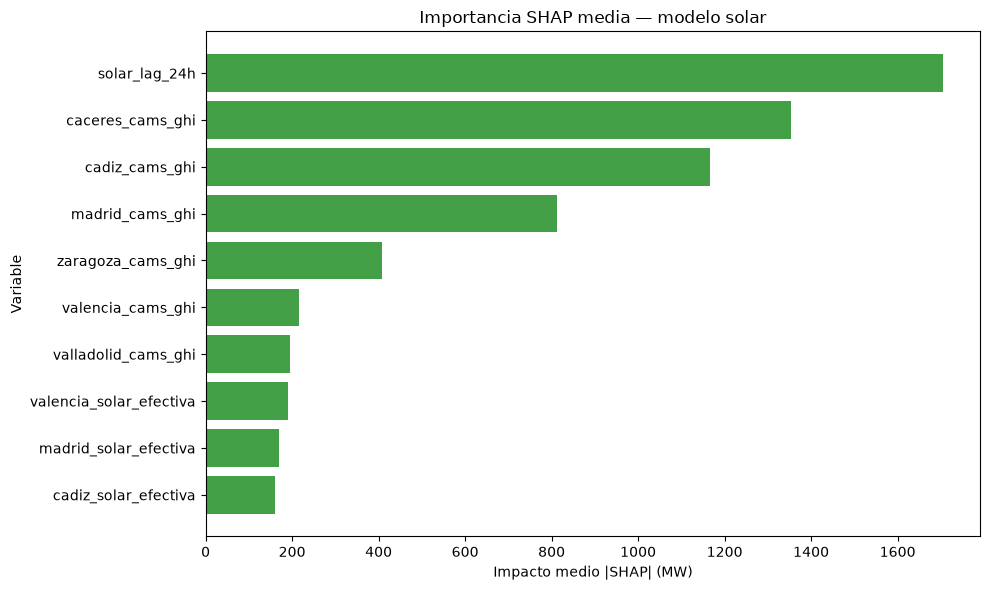

Gráfico SHAP solar actualizado.


In [87]:
# Muestra del conjunto de test para SHAP
X_shap_solar = X_solar_test[features_solar_final].sample(
    n=1000,
    random_state=42
)

# Explicador SHAP
explainer_solar = shap.TreeExplainer(modelo_final_solar)

# Valores SHAP
shap_values_solar = explainer_solar.shap_values(X_shap_solar)

# Importancia SHAP media absoluta
shap_importancia_solar = pd.DataFrame({
    "variable": X_shap_solar.columns,
    "importancia_shap": np.abs(shap_values_solar).mean(axis=0)
}).sort_values(
    "importancia_shap",
    ascending=False
).head(10)

# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importancia_solar["variable"],
    shap_importancia_solar["importancia_shap"],
    color="#43A047"
)

plt.gca().invert_yaxis()

plt.title("Importancia SHAP media — modelo solar")
plt.xlabel("Impacto medio |SHAP| (MW)")
plt.ylabel("Variable")

plt.tight_layout()

os.makedirs("assets", exist_ok=True)

plt.savefig(
    "assets/shap_importancia_solar.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Gráfico SHAP solar actualizado.")

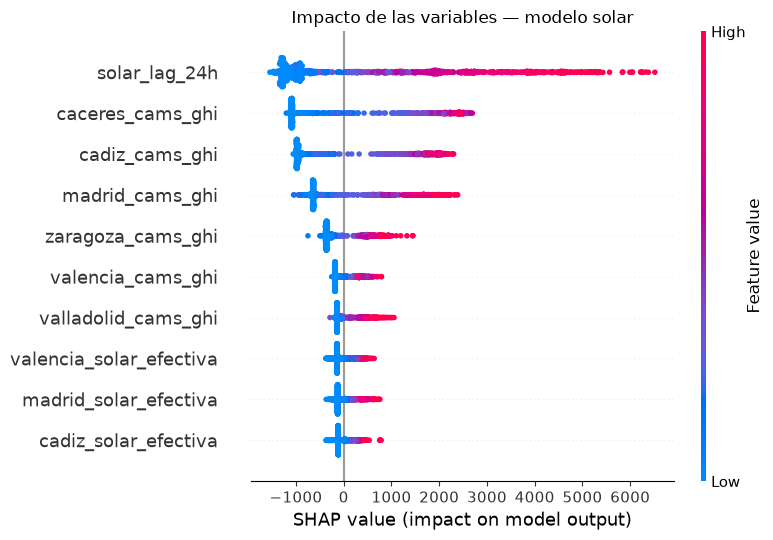

In [88]:
# SHAP summary plot — modelo solar
shap.summary_plot(
    shap_values_solar,
    X_shap_solar,
    max_display=10,
    show=False
)

plt.title("Impacto de las variables — modelo solar")
plt.tight_layout()
plt.show()



El análisis SHAP muestra que las predicciones solares dependen principalmente de **`solar_lag_24h`** y de las variables de **irradiancia GHI de CAMS**, especialmente en Cáceres, Cádiz y Madrid. Los valores elevados de estas variables tienden a incrementar la generación estimada, mientras que los valores bajos presentan generalmente un efecto negativo. En conjunto, el modelo combina de forma coherente la **persistencia temporal de la generación** con la **disponibilidad de recurso solar**.

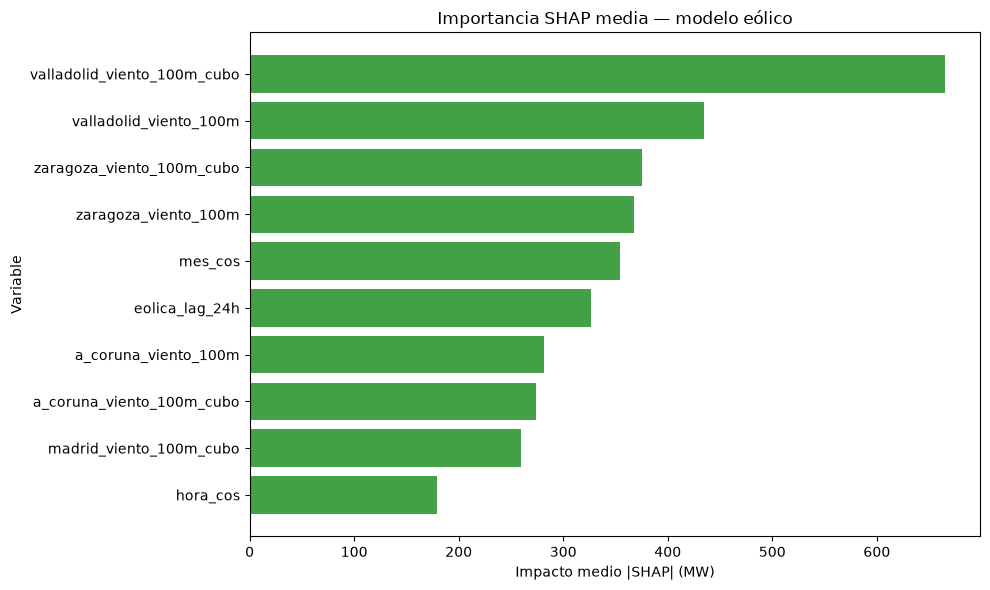

Gráfico SHAP eólico actualizado.


In [89]:
# Muestra del conjunto de test para SHAP
X_shap_eolica = X_eolica_test[features_eolica_final].sample(
    n=1000,
    random_state=42
)

# Explicador SHAP
explainer_eolica = shap.TreeExplainer(modelo_final_eolica)

# Valores SHAP
shap_values_eolica = explainer_eolica.shap_values(X_shap_eolica)

# Importancia SHAP media absoluta
shap_importancia_eolica = pd.DataFrame({
    "variable": X_shap_eolica.columns,
    "importancia_shap": np.abs(shap_values_eolica).mean(axis=0)
}).sort_values(
    "importancia_shap",
    ascending=False
).head(10)

# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importancia_eolica["variable"],
    shap_importancia_eolica["importancia_shap"],
    color="#43A047"
)

plt.gca().invert_yaxis()

plt.title("Importancia SHAP media — modelo eólico")
plt.xlabel("Impacto medio |SHAP| (MW)")
plt.ylabel("Variable")

plt.tight_layout()

os.makedirs("assets", exist_ok=True)

plt.savefig(
    "assets/shap_importancia_eolica.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Gráfico SHAP eólico actualizado.")

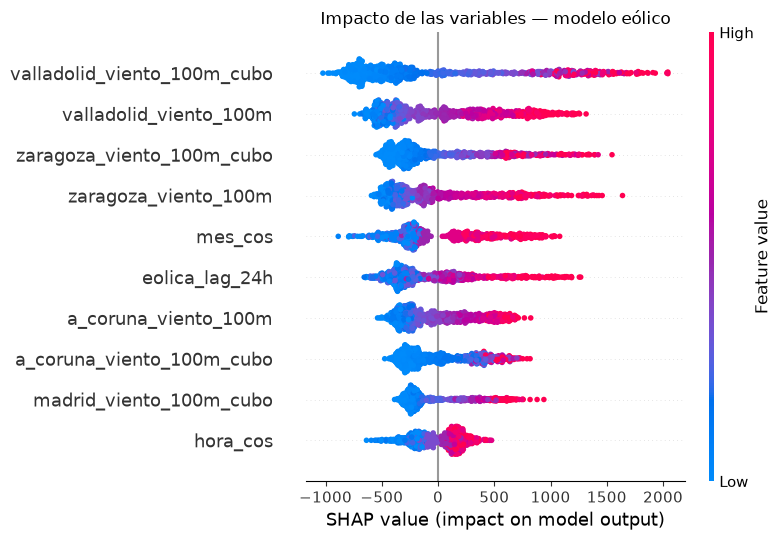

In [90]:
# SHAP summary plot — modelo eólico
shap.summary_plot(
    shap_values_eolica,
    X_shap_eolica,
    max_display=10,
    show=False
)

plt.title("Impacto de las variables — modelo eólico")
plt.tight_layout()
plt.show()

El análisis SHAP muestra que las predicciones eólicas están determinadas principalmente por las variables relacionadas con la **velocidad del viento a 100 metros**, especialmente en Valladolid y Zaragoza. Las transformaciones cúbicas presentan también una elevada importancia, reflejando la relación no lineal entre la velocidad del viento y la generación eólica. Además, variables como **`eolica_lag_24h`** y la componente temporal **`mes_cos`** aportan información adicional sobre la persistencia y estacionalidad de la generación. En general, valores elevados de velocidad del viento tienden a incrementar la predicción de generación eólica.

## 📉 Análisis de errores de los modelos finales

Una vez evaluado e interpretado el comportamiento de los modelos finales, se analiza la distribución de sus errores sobre el conjunto de test. El objetivo de este apartado es identificar posibles patrones en los residuos y estudiar en qué situaciones las predicciones presentan una mayor desviación respecto a los valores observados.

Este análisis se realiza exclusivamente con fines de diagnóstico e interpretación, sin utilizar sus resultados para modificar o volver a seleccionar los modelos.

In [91]:
# Dataframe de resultados sobre test


resultados_pred_test = pd.DataFrame({
    "solar_real": y_solar_test,
    "solar_pred": pred_solar_test,
    "eolica_real": y_eolica_test,
    "eolica_pred": pred_eolica_test
})

# Cálculo de residuos
resultados_pred_test["residuo_solar"] = (
    resultados_pred_test["solar_real"] -
    resultados_pred_test["solar_pred"]
)

resultados_pred_test["residuo_eolica"] = (
    resultados_pred_test["eolica_real"] -
    resultados_pred_test["eolica_pred"]
)

resultados_pred_test.head()

,solar_real,solar_pred,eolica_real,eolica_pred,residuo_solar,residuo_eolica
2025-07-01 00:00:00+02:00,565.0,501.183590,3689.0,4726.430278,63.816410,-1037.430278
2025-07-01 01:00:00+02:00,489.0,501.183590,2745.0,4083.031405,-12.183590,-1338.031405
2025-07-01 02:00:00+02:00,416.0,501.183590,2703.0,3809.184444,-85.183590,-1106.184444
2025-07-01 03:00:00+02:00,250.0,390.515210,2305.0,3484.304530,-140.515210,-1179.304530
2025-07-01 04:00:00+02:00,200.0,337.744851,2105.0,3312.607858,-137.744851,-1207.607858


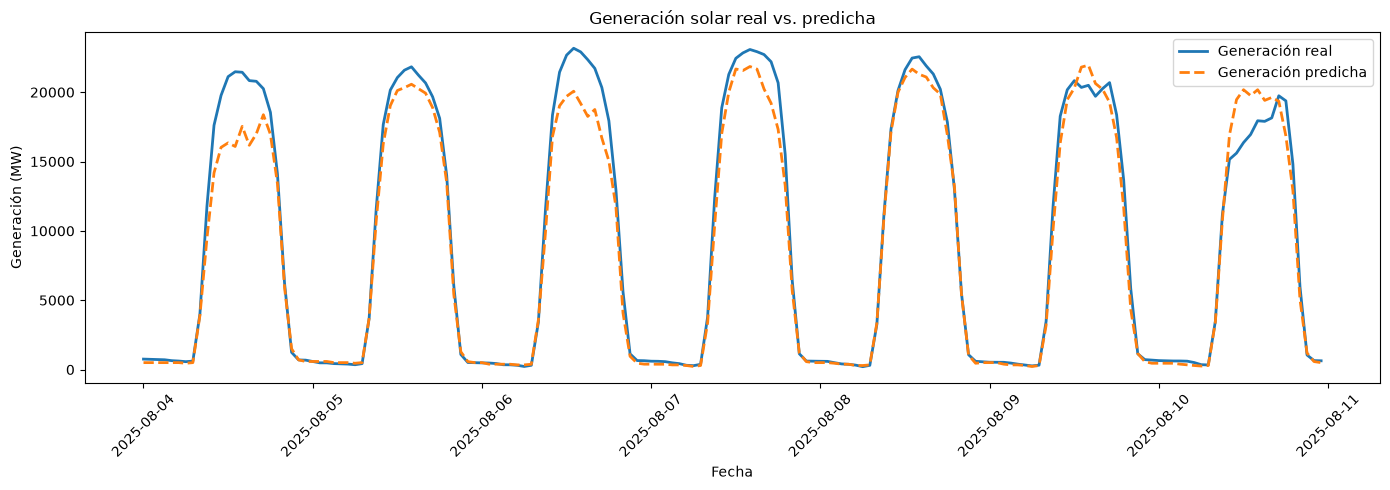

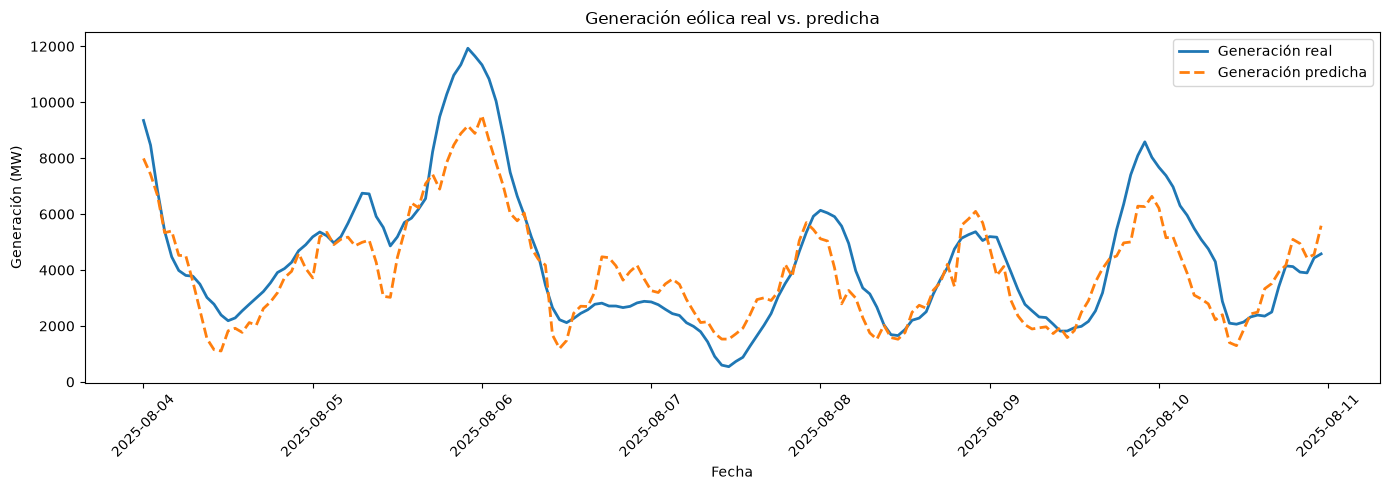

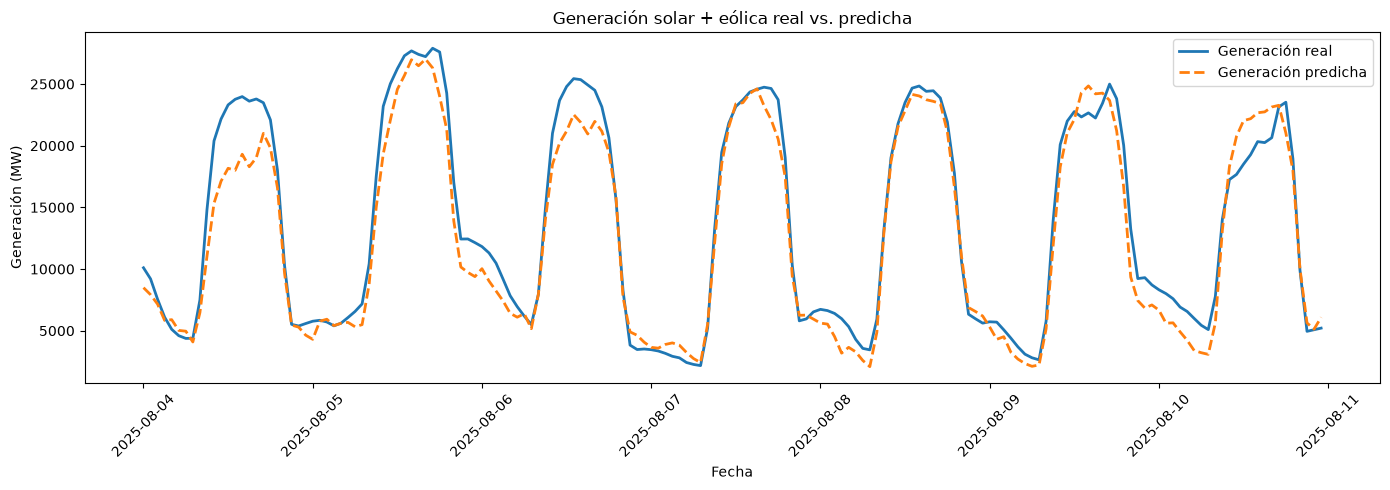

In [92]:
# Generación Real vs Predicha - Solar, Eólica y Total

# Periodo representativo: primera semana completa de agosto de 2025
inicio = "2025-08-04"
fin = "2025-08-10 23:00"

periodo = resultados_pred_test.loc[inicio:fin].copy()

# Generación renovable total
periodo["renovable_real"] = (
    periodo["solar_real"] +
    periodo["eolica_real"]
)

periodo["renovable_pred"] = (
    periodo["solar_pred"] +
    periodo["eolica_pred"]
)


# --- SOLAR ---

plt.figure(figsize=(14, 5))

plt.plot(
    periodo.index,
    periodo["solar_real"],
    label="Generación real",
    linewidth=2
)

plt.plot(
    periodo.index,
    periodo["solar_pred"],
    label="Generación predicha",
    linewidth=2,
    linestyle="--"
)

plt.title("Generación solar real vs. predicha")
plt.xlabel("Fecha")
plt.ylabel("Generación (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- EÓLICA ---

plt.figure(figsize=(14, 5))

plt.plot(
    periodo.index,
    periodo["eolica_real"],
    label="Generación real",
    linewidth=2
)

plt.plot(
    periodo.index,
    periodo["eolica_pred"],
    label="Generación predicha",
    linewidth=2,
    linestyle="--"
)

plt.title("Generación eólica real vs. predicha")
plt.xlabel("Fecha")
plt.ylabel("Generación (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- RENOVABLE TOTAL ---

plt.figure(figsize=(14, 5))

plt.plot(
    periodo.index,
    periodo["renovable_real"],
    label="Generación real",
    linewidth=2
)

plt.plot(
    periodo.index,
    periodo["renovable_pred"],
    label="Generación predicha",
    linewidth=2,
    linestyle="--"
)

plt.title("Generación solar + eólica real vs. predicha")
plt.xlabel("Fecha")
plt.ylabel("Generación (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La comparación entre los valores reales y predichos muestra que ambos modelos reproducen adecuadamente la evolución temporal de la generación. En el caso solar, el modelo captura con precisión el patrón diario, aunque se observan algunas desviaciones en los niveles máximos de generación. La generación eólica presenta una mayor variabilidad y diferencias más pronunciadas en determinados picos, si bien el modelo reproduce correctamente su tendencia general.

Al combinar ambas tecnologías, la predicción conjunta mantiene una elevada correspondencia con la generación solar-eólica observada, mostrando la capacidad de RenewAI para estimar no solo cada tecnología individualmente, sino también su aportación agregada al sistema eléctrico.

### 🗑️ Análisis de residuos

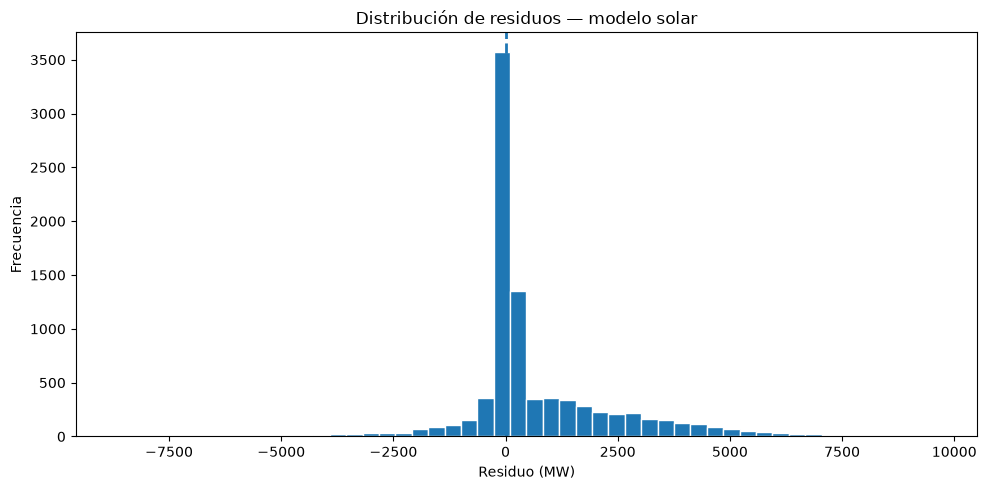

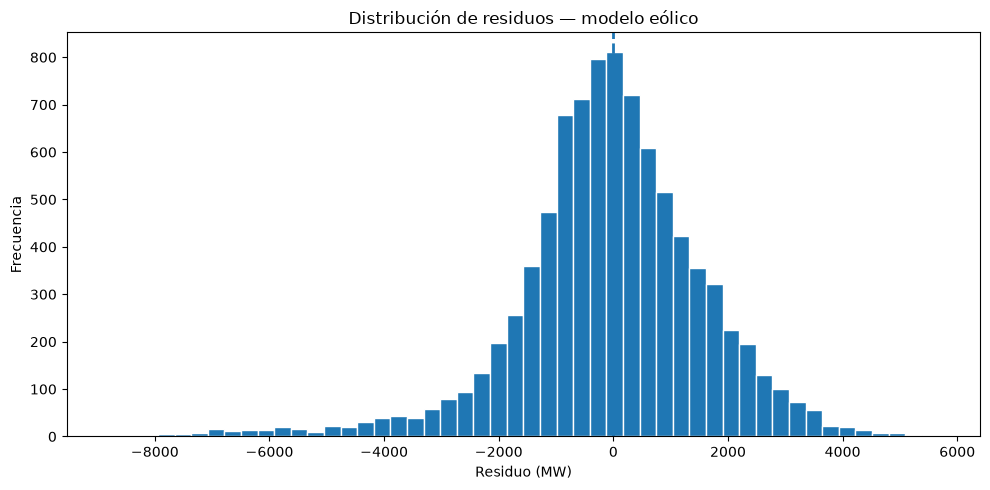

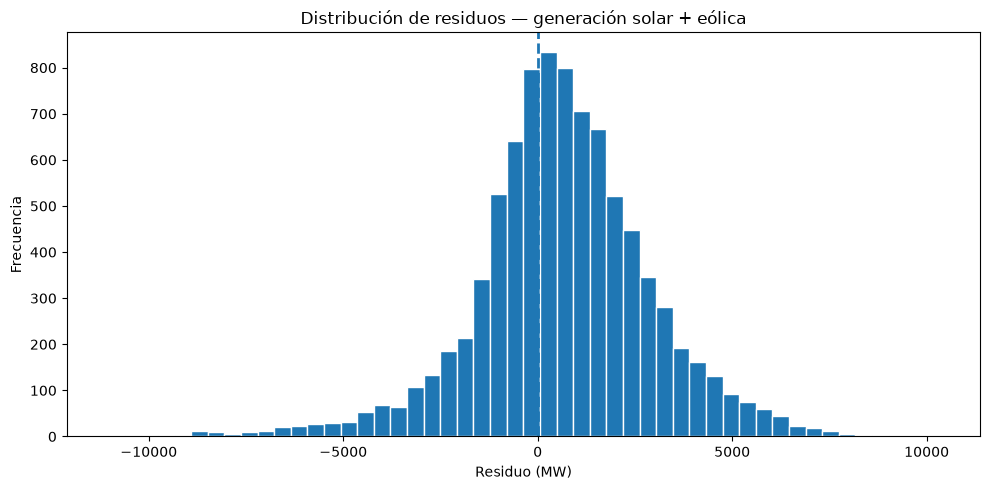

Residuo medio solar: 709.26 MW
Residuo medio eólico: -72.51 MW
Residuo medio solar + eólico: 636.75 MW


In [93]:
# Análisis de residuos — Solar, Eólica y Total
# Generación solar-eólica total
resultados_pred_test["renovable_real"] = (
    resultados_pred_test["solar_real"] +
    resultados_pred_test["eolica_real"]
)

resultados_pred_test["renovable_pred"] = (
    resultados_pred_test["solar_pred"] +
    resultados_pred_test["eolica_pred"]
)

# Residuos = valor real - valor predicho
resultados_pred_test["residuo_solar"] = (
    resultados_pred_test["solar_real"] -
    resultados_pred_test["solar_pred"]
)

resultados_pred_test["residuo_eolica"] = (
    resultados_pred_test["eolica_real"] -
    resultados_pred_test["eolica_pred"]
)

resultados_pred_test["residuo_renovable"] = (
    resultados_pred_test["renovable_real"] -
    resultados_pred_test["renovable_pred"]
)


# --- SOLAR ---

plt.figure(figsize=(10, 5))

plt.hist(
    resultados_pred_test["residuo_solar"],
    bins=50,
    edgecolor="white"
)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Distribución de residuos — modelo solar")
plt.xlabel("Residuo (MW)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


# --- EÓLICA ---

plt.figure(figsize=(10, 5))

plt.hist(
    resultados_pred_test["residuo_eolica"],
    bins=50,
    edgecolor="white"
)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Distribución de residuos — modelo eólico")
plt.xlabel("Residuo (MW)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


# --- SOLAR + EÓLICA ---

plt.figure(figsize=(10, 5))

plt.hist(
    resultados_pred_test["residuo_renovable"],
    bins=50,
    edgecolor="white"
)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Distribución de residuos — generación solar + eólica")
plt.xlabel("Residuo (MW)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


# Residuos medios
print(
    "Residuo medio solar:",
    round(resultados_pred_test["residuo_solar"].mean(), 2),
    "MW"
)

print(
    "Residuo medio eólico:",
    round(resultados_pred_test["residuo_eolica"].mean(), 2),
    "MW"
)

print(
    "Residuo medio solar + eólico:",
    round(resultados_pred_test["residuo_renovable"].mean(), 2),
    "MW"
)

El análisis de residuos permite estudiar posibles sesgos sistemáticos en las predicciones de los modelos. En el caso solar, el residuo medio es de **709,26 MW**, indicando una cierta tendencia a infraestimar la generación real. La distribución presenta además una concentración elevada de errores próximos a cero, junto con una cola positiva asociada a determinados periodos de mayor generación.

Para la generación eólica, el residuo medio es de **−72,51 MW**, considerablemente más próximo a cero, por lo que no se observa un sesgo sistemático relevante, aunque existen errores puntuales de mayor magnitud.

Al combinar ambas tecnologías, el residuo medio se mantiene positivo debido principalmente al sesgo observado en el modelo solar. En conjunto, los modelos reproducen adecuadamente la dinámica general de la generación renovable, aunque presentan mayores desviaciones en determinados episodios de elevada producción.

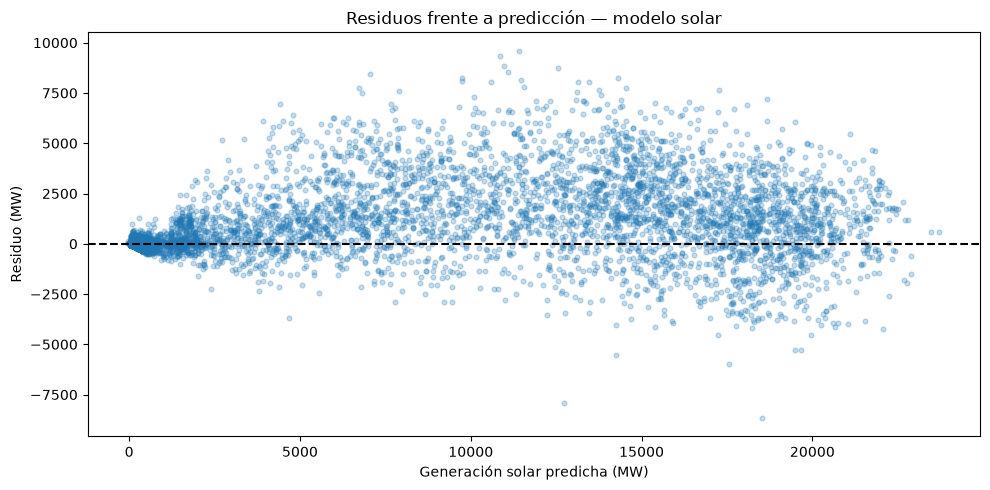

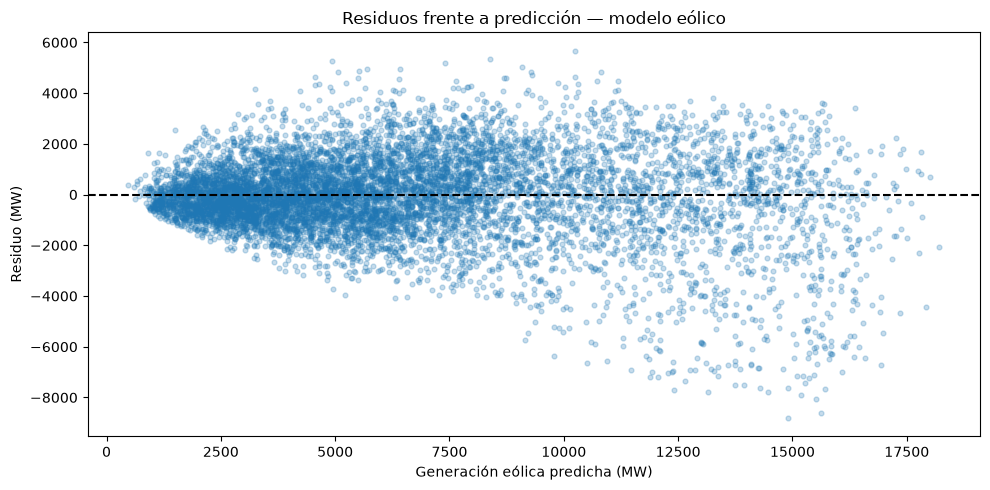

In [94]:
# Residuos frente a valores predichos

# Modelo solar
plt.figure(figsize=(10, 5))

plt.scatter(
    pred_solar_test,
    resultados_pred_test["residuo_solar"],
    alpha=0.25,
    s=12
)

plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Generación solar predicha (MW)")
plt.ylabel("Residuo (MW)")
plt.title("Residuos frente a predicción — modelo solar")

plt.tight_layout()
plt.show()


# Modelo eólico
plt.figure(figsize=(10, 5))

plt.scatter(
    pred_eolica_test,
    resultados_pred_test["residuo_eolica"],
    alpha=0.25,
    s=12
)

plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Generación eólica predicha (MW)")
plt.ylabel("Residuo (MW)")
plt.title("Residuos frente a predicción — modelo eólico")

plt.tight_layout()
plt.show()

Los gráficos de residuos muestran que la magnitud de los errores tiende a aumentar conforme se incrementa el nivel de generación predicha. Este patrón es especialmente visible en el modelo solar, donde los errores son reducidos durante los periodos de baja generación y presentan una mayor dispersión en niveles medios y altos. Además, se observa una mayor presencia de residuos positivos, coherente con la tendencia a la infraestimación identificada anteriormente.

En el modelo eólico, los residuos se distribuyen de forma más equilibrada alrededor de cero, aunque su dispersión también aumenta para niveles elevados de generación. Por tanto, ambos modelos presentan una mayor incertidumbre en los periodos de mayor producción, siendo el sesgo global más reducido en el caso eólico.

## 📊 Monitorización del sistema eléctrico y aplicación de RenewAI

Como se ha mencionado anteriormente, además de la predicción individual de la generación solar y eólica, RenewAI incorpora una capa de monitorización destinada a contextualizar las estimaciones dentro del sistema eléctrico español. Para ello, las predicciones de ambos modelos se combinan con los datos de demanda eléctrica, permitiendo estimar la cobertura solar-eólica, definida como el porcentaje de la demanda que podría ser cubierto conjuntamente por ambas tecnologías.

Adicionalmente, se incorpora el precio mayorista de la electricidad como variable de contexto, con el objetivo de analizar la relación existente entre la disponibilidad de generación renovable y las condiciones observadas en el mercado eléctrico.

In [95]:
# Dataset de monitorización sobre el conjunto de test

monitorizacion = pd.DataFrame(
    index=y_solar_test.index
)

monitorizacion["solar_real_mw"] = y_solar_test
monitorizacion["solar_pred_mw"] = pred_solar_test

monitorizacion["eolica_real_mw"] = y_eolica_test
monitorizacion["eolica_pred_mw"] = pred_eolica_test

monitorizacion["renovable_real_mw"] = (
    monitorizacion["solar_real_mw"] +
    monitorizacion["eolica_real_mw"]
)

monitorizacion["renovable_pred_mw"] = (
    monitorizacion["solar_pred_mw"] +
    monitorizacion["eolica_pred_mw"]
)

monitorizacion["total_load_mw"] = dataset.loc[
    monitorizacion.index,
    "total_load_mw"
]

monitorizacion["precio_eur_mwh"] = dataset.loc[
    monitorizacion.index,
    "precio_eur_mwh"
]

monitorizacion.head()

,solar_real_mw,solar_pred_mw,eolica_real_mw,eolica_pred_mw,renovable_real_mw,renovable_pred_mw,total_load_mw,precio_eur_mwh
2025-07-01 00:00:00+02:00,565.0,501.183590,3689.0,4726.430278,4254.0,5227.613868,31554.0,129.98
2025-07-01 01:00:00+02:00,489.0,501.183590,2745.0,4083.031405,3234.0,4584.214995,29642.0,118.32
2025-07-01 02:00:00+02:00,416.0,501.183590,2703.0,3809.184444,3119.0,4310.368034,28173.0,116.70
2025-07-01 03:00:00+02:00,250.0,390.515210,2305.0,3484.304530,2555.0,3874.819740,27346.0,115.98
2025-07-01 04:00:00+02:00,200.0,337.744851,2105.0,3312.607858,2305.0,3650.352709,26736.0,114.80


In [96]:
# COBERTURA SOLAR-EÓLICA DE LA DEMANDA


monitorizacion["cobertura_real_pct"] = (
    monitorizacion["renovable_real_mw"] /
    monitorizacion["total_load_mw"]
) * 100

monitorizacion["cobertura_pred_pct"] = (
    monitorizacion["renovable_pred_mw"] /
    monitorizacion["total_load_mw"]
) * 100


# Resumen
print("Cobertura media real:",
      round(monitorizacion["cobertura_real_pct"].mean(), 2), "%")

print("Cobertura media predicha:",
      round(monitorizacion["cobertura_pred_pct"].mean(), 2), "%")


monitorizacion[
    [
        "total_load_mw",
        "renovable_real_mw",
        "renovable_pred_mw",
        "cobertura_real_pct",
        "cobertura_pred_pct"
    ]
].head()

Cobertura media real: 47.12 %
Cobertura media predicha: 45.08 %


,total_load_mw,renovable_real_mw,renovable_pred_mw,cobertura_real_pct,cobertura_pred_pct
2025-07-01 00:00:00+02:00,31554.0,4254.0,5227.613868,13.481651,16.567199
2025-07-01 01:00:00+02:00,29642.0,3234.0,4584.214995,10.910195,15.465269
2025-07-01 02:00:00+02:00,28173.0,3119.0,4310.368034,11.070883,15.299642
2025-07-01 03:00:00+02:00,27346.0,2555.0,3874.819740,9.343231,14.169603
2025-07-01 04:00:00+02:00,26736.0,2305.0,3650.352709,8.621335,13.653324


In [97]:
# EVALUACIÓN DE LA COBERTURA ESTIMADA


mae_cobertura = mean_absolute_error(
    monitorizacion["cobertura_real_pct"],
    monitorizacion["cobertura_pred_pct"]
)

rmse_cobertura = np.sqrt(
    mean_squared_error(
        monitorizacion["cobertura_real_pct"],
        monitorizacion["cobertura_pred_pct"]
    )
)

r2_cobertura = r2_score(
    monitorizacion["cobertura_real_pct"],
    monitorizacion["cobertura_pred_pct"]
)

print("MAE cobertura:", round(mae_cobertura, 2), "p.p.")
print("RMSE cobertura:", round(rmse_cobertura, 2), "p.p.")
print("R² cobertura:", round(r2_cobertura, 3))

MAE cobertura: 6.55 p.p.
RMSE cobertura: 8.88 p.p.
R² cobertura: 0.875


La cobertura solar-eólica estimada presenta un **MAE de 6,55 puntos porcentuales**, un **RMSE de 8,88 puntos porcentuales** y un **R² de 0,875**. Por tanto, las predicciones combinadas de generación solar y eólica permiten reproducir aproximadamente el 87,5 % de la variabilidad observada en la cobertura real de la demanda durante el periodo de test.

La cobertura media estimada se sitúa en el 45,08 %, frente al 47,12 % observado, mostrando una ligera tendencia a la infraestimación coherente con los resultados obtenidos previamente en el análisis de los modelos de generación.

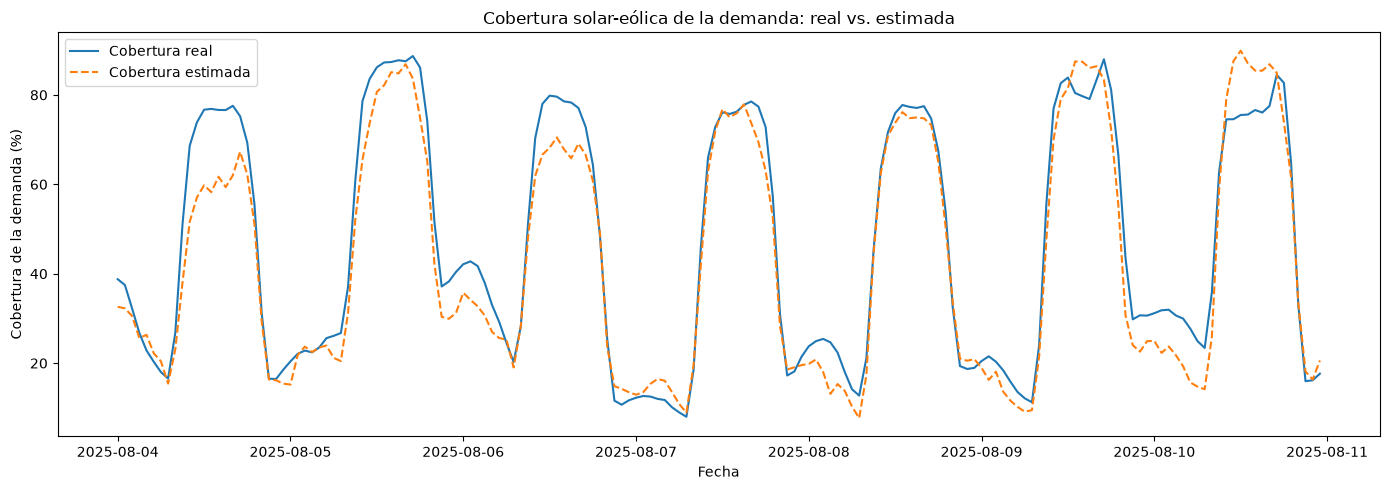

In [98]:
# COBERTURA REAL VS. ESTIMADA


# Seleccionamos una semana representativa
inicio = "2025-08-04"
fin = "2025-08-10"

muestra_cobertura = monitorizacion.loc[inicio:fin]

plt.figure(figsize=(14, 5))

plt.plot(
    muestra_cobertura.index,
    muestra_cobertura["cobertura_real_pct"],
    label="Cobertura real"
)

plt.plot(
    muestra_cobertura.index,
    muestra_cobertura["cobertura_pred_pct"],
    linestyle="--",
    label="Cobertura estimada"
)

plt.title("Cobertura solar-eólica de la demanda: real vs. estimada")
plt.xlabel("Fecha")
plt.ylabel("Cobertura de la demanda (%)")
plt.legend()

plt.tight_layout()
plt.show()

La evolución de la cobertura estimada reproduce de forma adecuada el patrón observado en la cobertura real de la demanda. Las principales discrepancias se concentran en algunos máximos y mínimos, aunque el modelo captura correctamente la dinámica temporal general de la contribución conjunta de la generación solar y eólica.

### 💶 Contextualización mediante el precio de la electricidad

El precio mayorista de la electricidad se incorpora como un indicador adicional de contexto dentro de RenewAI. Al igual que la demanda, no se utiliza como predictor directo de la generación renovable, sino como información complementaria para interpretar las condiciones del sistema eléctrico.

A partir de la cobertura solar-eólica estimada por los modelos, se analiza su relación con el precio observado de la electricidad, permitiendo contextualizar los periodos de mayor o menor disponibilidad renovable dentro de las condiciones del mercado eléctrico.

In [99]:
# INCORPORACIÓN DEL PRECIO A LA MONITORIZACIÓN


monitorizacion["precio_eur_mwh"] = dataset.loc[
    monitorizacion.index,
    "precio_eur_mwh"
]

monitorizacion[
    ["cobertura_pred_pct", "cobertura_real_pct", "precio_eur_mwh"]
].head()

,cobertura_pred_pct,cobertura_real_pct,precio_eur_mwh
2025-07-01 00:00:00+02:00,16.567199,13.481651,129.98
2025-07-01 01:00:00+02:00,15.465269,10.910195,118.32
2025-07-01 02:00:00+02:00,15.299642,11.070883,116.70
2025-07-01 03:00:00+02:00,14.169603,9.343231,115.98
2025-07-01 04:00:00+02:00,13.653324,8.621335,114.80


In [100]:
# RELACIÓN ENTRE COBERTURA RENOVABLE Y PRECIO


correlacion_precio = pd.DataFrame({
    "Cobertura real": [
        monitorizacion["cobertura_real_pct"].corr(
            monitorizacion["precio_eur_mwh"]
        )
    ],
    "Cobertura estimada": [
        monitorizacion["cobertura_pred_pct"].corr(
            monitorizacion["precio_eur_mwh"]
        )
    ]
}, index=["Correlación con precio"])

correlacion_precio.round(3)

,Cobertura real,Cobertura estimada
Correlación con precio,-0.778,-0.808


Se observa una relación negativa elevada entre la cobertura solar-eólica y el precio mayorista de la electricidad. La cobertura real presenta una correlación de −0,778 con el precio, mientras que la cobertura estimada por RenewAI alcanza −0,808. La similitud entre ambos valores indica que las predicciones de generación permiten reproducir razonablemente la relación observada entre disponibilidad renovable y condiciones del mercado eléctrico. Este resultado refuerza la utilidad de la cobertura estimada como indicador de monitorización, aunque la relación observada debe interpretarse como una asociación y no como evidencia de causalidad.

## 🌿 Preparación de la aplicación Streamlit

En esta sección se preparan y exportan los modelos y datos necesarios para integrar los resultados de RenewAI en una aplicación web interactiva desarrollada con Streamlit.

In [101]:
import joblib

# Crear carpeta si no existe
os.makedirs("models", exist_ok=True)

# Guardar modelos finales
joblib.dump(
    modelo_final_solar,
    "models/modelo_solar.joblib"
)

joblib.dump(
    modelo_final_eolica,
    "models/modelo_eolica.joblib"
)

print("Modelos finales guardados correctamente.")

Modelos finales guardados correctamente.


In [102]:
# Guardar listas de variables utilizadas por los modelos finales

joblib.dump(
    features_solar_final,
    "models/features_solar.joblib"
)

joblib.dump(
    features_eolica_final,
    "models/features_eolica.joblib"
)

print("Variables guardadas.")

print("Solar:", len(features_solar_final), "variables")
print("Eólica:", len(features_eolica_final), "variables")

Variables guardadas.
Solar: 13 variables
Eólica: 42 variables


In [103]:
# Dataset final para la aplicación

os.makedirs("data", exist_ok=True)

# Partimos del dataset original correspondiente al periodo de test,
# para conservar todas las variables utilizadas por los modelos
datos_app = dataset.loc[monitorizacion.index].copy()

# Añadir los resultados de monitorización
for col in monitorizacion.columns:
    if col not in datos_app.columns:
        datos_app[col] = monitorizacion[col]

# Nombres utilizados por la aplicación
datos_app["solar_real_mw"] = datos_app["solar_mw"]
datos_app["eolica_real_mw"] = datos_app["eolica_onshore_mw"]
datos_app["demanda_mw"] = datos_app["total_load_mw"]

# Variables de entrada del modelo solar
for var in features_solar_final:
    datos_app[f"solar_input__{var}"] = datos_app[var]

# Variables de entrada del modelo eólico
for var in features_eolica_final:
    datos_app[f"eolica_input__{var}"] = datos_app[var]

# Fecha/hora como columna
datos_app.index.name = "fecha_hora"
datos_app = datos_app.reset_index()

# Exportar
datos_app.to_csv(
    "data/datos_app.csv",
    index=False
)

print("datos_app.csv actualizado correctamente.")
print("Dimensiones:", datos_app.shape)

datos_app.csv actualizado correctamente.
Dimensiones: (8758, 238)


In [104]:
metricas_app = {
    "solar": {
        "MAE": 1015.88,
        "RMSE": 1786.94,
        "R2": 0.948
    },
    "eolica": {
        "MAE": 1201.27,
        "RMSE": 1649.55,
        "R2": 0.831
    },
    "cobertura": {
        "MAE": 6.55,
        "RMSE": 8.88,
        "R2": 0.875
    }
}

joblib.dump(
    metricas_app,
    "models/metricas_modelos.joblib"
)

print("Métricas actualizadas.")

Métricas actualizadas.
